# 不動産データ収集基盤 — Real Estate Data Collection Pipeline

## 目的
指定住所（例: 東京都江東区亀戸）に対して、以下の3種類のデータを収集・整形・確認する。

| # | データ | ソース | 用途 |
|---|--------|--------|------|
| 1 | 売出し中物件（売買） | SUUMO | 表面利回り / 取得コスト把握 |
| 2 | 賃貸募集中物件 | SUUMO | 想定賃料の推定 |
| 3 | 地価公示価格（過去10年） | 国土交通省 土地総合情報システム API | 地価トレンド把握 |

## スコープ
- **今回**: データ収集・クレンジング・確認まで（この Notebook）
- **次段階**: キャッシュフローシミュレーション、投資判断指標の算出

## 注意事項
- スクレイピング対象サイト（SUUMO）の HTML 構造は予告なく変更される可能性がある
- CSS セレクタには複数候補を持たせ、構造変更への耐性を確保している
- サイト負荷軽減のため、リクエスト間に sleep を入れ、User-Agent を設定している
- robots.txt を尊重し、個人利用・分析目的の範囲で利用すること

In [1]:
# === 依存ライブラリ ===
# 標準ライブラリ
import re
import os
import json
import time
import random
import logging
import unicodedata
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple, Any
from urllib.parse import urlencode, urljoin, urlparse, parse_qs

# サードパーティ
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

# オプション: tqdm（なければフォールバック）
try:
    from tqdm.notebook import tqdm
except ImportError:
    try:
        from tqdm import tqdm
    except ImportError:
        def tqdm(iterable, **kwargs):
            return iterable

pd.set_option("display.max_columns", 50)

# バージョン表示
print(f"Python:   {__import__('sys').version}")
print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"requests: {requests.__version__}")
print(f"bs4:      {__import__('bs4').__version__}")
print(f"display.max_columns: {pd.get_option('display.max_columns')}")

Python:   3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
pandas:   2.3.3
numpy:    2.4.3
requests: 2.32.5
bs4:      4.14.3
display.max_columns: 50


## 設定パラメータ
ターゲット住所・スクレイピング設定・出力先をここで一括管理する。  
住所を変える場合は、このセルだけを書き換えて再実行すればよい。

In [2]:

 # === 設定パラメータ ===

# --- ターゲット住所 ---
# 使いたい候補を TARGET_KEY で切り替える
TARGET_CANDIDATES = {
    "koto_kameido": {
        "address": "東京都江東区亀戸",
        "prefecture": "東京都",
        "municipality": "江東区",
        "town": "亀戸",
    },
    "shinagawa_minamioi": {
        "address": "東京都品川区南大井",
        "prefecture": "東京都",
        "municipality": "品川区",
        "town": "南大井",
    },
}

# 現在の対象（必要に応じてキーを変更）
TARGET_KEY = "koto_kameido"
_target = TARGET_CANDIDATES[TARGET_KEY]
TARGET_ADDRESS = _target["address"]
TARGET_PREFECTURE = _target["prefecture"]
TARGET_MUNICIPALITY = _target["municipality"]
TARGET_TOWN = _target["town"]

# --- SUUMO URL（ターゲット連動）
# ここを直書きすると TARGET_KEY とズレやすいため、候補辞書で一元管理する
SUUMO_URL_CANDIDATES = {
    # 旧検証用（江東区×亀戸フリーワード）
    "koto_kameido": {
        "sale_url": (
            "https://suumo.jp/jj/bukken/ichiran/JJ012FC001/"
            "?ar=030&bs=011&ta=13&sc=13108"
            "&cn=9999999&kb=1&kt=9999999"
            "&mb=0&mt=9999999&et=9999999"
            "&fw2=%E4%BA%80%E6%88%B8"
        ),
        "rent_url": "https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/",
        "area_code": "13108",
    },
    # 品川区×南大井（ユーザー指定リンク）
    "shinagawa_minamioi": {
        "sale_url": (
            "https://suumo.jp/jj/bukken/ichiran/JJ012FC001/"
            "?jj012fi20202Kbn=3&initKbn=0&displayClass=dn&disabledClass=false"
            "&ar=030&bs=011&ta=13&sc=13109&scTemp=13109"
            "&cn=9999999&kb=1&kt=9999999"
            "&mb=0&mt=9999999&et=9999999"
            "&fw2=%E5%8D%97%E5%A4%A7%E4%BA%95"
        ),
        "rent_url": "https://suumo.jp/chintai/tokyo/sc_shinagawa/oz_13109023/",
        "area_code": "13109",
    },
}
_suumo = SUUMO_URL_CANDIDATES[TARGET_KEY]
SUUMO_SALE_URL = _suumo["sale_url"]
SUUMO_RENT_URL = _suumo["rent_url"]

# --- 検討物件（比較用。TARGET_KEY と連動） ---
# 売買チャート: price/㎡単価/散布図で比較
# 賃貸チャート: rent/㎡単価/散布図で比較（rent_jpy が未設定なら比較線を出さない）
PROPERTY_CANDIDATES = {
    "koto_kameido": {
        "label": "ガリシア亀戸",
        "area_sqm": 25.56,
        "sale_price_jpy": 38_800_000,
        "rent_jpy": 122_900,
    },
    "shinagawa_minamioi": {
        "label": "ガリシアレジデンス品川パークサイド",
        "area_sqm": 25.03,
        "sale_price_jpy": 43_900_000,
        "rent_jpy": 142_500,
    },
}
_prop = PROPERTY_CANDIDATES[TARGET_KEY]
PROP_LABEL = _prop["label"]
PROP_AREA_SQM = _prop["area_sqm"]
PROP_SALE_PRICE_JPY = _prop.get("sale_price_jpy")
PROP_RENT_JPY = _prop.get("rent_jpy")

# --- スクレイピング制御 ---
YEARS_BACK = 10
MAX_PAGES_SALE = 10
MAX_PAGES_RENT = None  # None の場合は一覧1ページ目から自動推定（リンク優先）
RENT_PAGE_SIZE = 30
RENT_ENABLE_ADDRESS_FILTER = False
RENT_ENABLE_DETAIL_ENRICHMENT = False
REQUEST_SLEEP_MIN = 1.0
REQUEST_SLEEP_MAX = 2.5
REQUEST_TIMEOUT = 20
MAX_RETRIES = 3
USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/120.0.0.0 Safari/537.36"
 )

# --- 不動産取引価格情報 API（国土交通省 不動産情報ライブラリ） ---
# APIキー取得: https://www.reinfolib.mlit.go.jp/app/user/create にて無料登録
LAND_PRICE_API_URL = "https://www.reinfolib.mlit.go.jp/ex-api/external/XIT001"
LAND_PRICE_AREA_CODE = _suumo["area_code"]  # 市区町村コード5桁 (先頭2桁=都道府県コード「13」)
REINFOLIB_API_KEY = "18744de26d474a9fa5c4162024d9ccb8"

# --- 出力先 ---
OUTPUT_DIR = Path("output")
RAW_DIR = OUTPUT_DIR / "raw"
PROCESSED_DIR = OUTPUT_DIR / "processed"

# --- フラグ ---
ENABLE_SAVE = True
ENABLE_DEBUG_PREVIEW = True

# 設定サマリ表示
print("=== 設定サマリ ===")
print(f"  対象キー:     {TARGET_KEY}")
print(f"  対象住所:     {TARGET_ADDRESS}")
print(f"  売買 最大ページ: {MAX_PAGES_SALE}")
print(f"  賃貸 最大ページ: {MAX_PAGES_RENT} (None=自動)")
print(f"  賃貸 住所フィルタ: {RENT_ENABLE_ADDRESS_FILTER}")
print(f"  賃貸 詳細補完:   {RENT_ENABLE_DETAIL_ENRICHMENT}")
print(f"  地価 遡及年数:  {YEARS_BACK}")
print(f"  出力先:       {OUTPUT_DIR.resolve()}")
print(f"  保存有効:     {ENABLE_SAVE}")
print(f"  売買URL:      {SUUMO_SALE_URL[:80]}...")
print(f"  賃貸URL:      {SUUMO_RENT_URL}")
print(f"  地価市区町村:  {LAND_PRICE_AREA_CODE}")
print(f"  検討物件:     {PROP_LABEL} / {PROP_AREA_SQM}㎡ / 売買={PROP_SALE_PRICE_JPY} / 賃貸={PROP_RENT_JPY}")
if REINFOLIB_API_KEY:
    print(f"  不動産APIキー: 設定済み")
else:
    print(f"  不動産APIキー: ⚠ 未設定 — https://www.reinfolib.mlit.go.jp/app/user/create で無料登録")


=== 設定サマリ ===
  対象キー:     koto_kameido
  対象住所:     東京都江東区亀戸
  売買 最大ページ: 10
  賃貸 最大ページ: None (None=自動)
  賃貸 住所フィルタ: False
  賃貸 詳細補完:   False
  地価 遡及年数:  10
  出力先:       /home/kazumasa/projects/notebooks/output
  保存有効:     True
  売買URL:      https://suumo.jp/jj/bukken/ichiran/JJ012FC001/?ar=030&bs=011&ta=13&sc=13108&cn=9...
  賃貸URL:      https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/
  地価市区町村:  13108
  検討物件:     ガリシア亀戸 / 25.56㎡ / 売買=38800000 / 賃貸=122900
  不動産APIキー: 設定済み


In [3]:
# === 出力ディレクトリ作成 & ロギング設定 ===
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ロガー設定
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger("real_estate_collector")
logger.setLevel(logging.INFO)

logger.info(f"データ収集セッション開始: 対象={TARGET_ADDRESS}")
logger.info(f"出力先: raw={RAW_DIR.resolve()}, processed={PROCESSED_DIR.resolve()}")

2026-04-05 11:25:59 [INFO] データ収集セッション開始: 対象=東京都江東区亀戸
2026-04-05 11:25:59 [INFO] 出力先: raw=/home/kazumasa/projects/notebooks/output/raw, processed=/home/kazumasa/projects/notebooks/output/processed


## ユーティリティ関数

### HTTP リクエスト（レートリミット / リトライ / User-Agent）
- 全てのページ取得は `fetch_page()` を経由する
- ランダム sleep + 指数バックオフリトライで安全にリクエスト
- 失敗時は例外でクラッシュせず `(None, status_code, url)` を返す

In [4]:
# === HTTP リクエストユーティリティ ===

def fetch_page(
    url: str,
    params: Optional[Dict] = None,
    max_retries: int = MAX_RETRIES,
    timeout: int = REQUEST_TIMEOUT,
) -> Tuple[Optional[str], int, str]:
    """
    ページを取得する。リトライ・sleep・User-Agent 付き。

    Returns:
        (html_text or None, status_code, final_url)
    """
    headers = {
        "User-Agent": USER_AGENT,
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "ja,en-US;q=0.7,en;q=0.3",
    }

    for attempt in range(1, max_retries + 1):
        # リクエスト前に sleep
        sleep_sec = random.uniform(REQUEST_SLEEP_MIN, REQUEST_SLEEP_MAX)
        time.sleep(sleep_sec)

        try:
            resp = requests.get(
                url, params=params, headers=headers, timeout=timeout
            )
            if resp.status_code == 200:
                resp.encoding = resp.apparent_encoding
                return (resp.text, resp.status_code, resp.url)

            logger.warning(
                f"HTTP {resp.status_code} on attempt {attempt}/{max_retries}: {url}"
            )
            if resp.status_code in (403, 429):
                # バックオフを長めに
                backoff = sleep_sec * (2 ** attempt)
                logger.info(f"Rate limit / forbidden — backing off {backoff:.1f}s")
                time.sleep(backoff)
            elif resp.status_code >= 500:
                time.sleep(sleep_sec * attempt)
            else:
                # 4xx (404 等) はリトライしても無駄
                return (None, resp.status_code, resp.url)

        except requests.exceptions.Timeout:
            logger.warning(f"Timeout on attempt {attempt}/{max_retries}: {url}")
        except requests.exceptions.ConnectionError as e:
            logger.warning(f"ConnectionError on attempt {attempt}/{max_retries}: {e}")
        except requests.exceptions.RequestException as e:
            logger.error(f"RequestException: {e}")
            return (None, 0, url)

    logger.error(f"全 {max_retries} 回のリトライ失敗: {url}")
    return (None, 0, url)


def parse_html(html: str) -> BeautifulSoup:
    """HTML 文字列を BeautifulSoup オブジェクトに変換"""
    return BeautifulSoup(html, "html.parser")


# 動作確認: Google にリクエスト（軽量）
_test_html, _test_status, _test_url = fetch_page("https://httpbin.org/get")
print(f"fetch_page テスト: status={_test_status}, url={_test_url}, html_len={len(_test_html) if _test_html else 0}")

fetch_page テスト: status=200, url=https://httpbin.org/get, html_len=507


### 住所正規化 & マッチング
- 全角数字→半角、余分な空白除去、丁目/番地/号の正規化
- `match_address()` は `matching_strategy` パラメータで将来ジオコーディングに拡張可能

In [5]:
# === 住所正規化 & マッチング ===

def normalize_address(address_str: str) -> str:
    """
    住所文字列を正規化する。
    - 全角英数字 → 半角
    - 余分な空白除去
    - 丁目・番地・号 のバリエーション統一
    - ビル名・部屋番号の除去（比較用）
    """
    if not address_str:
        return ""
    # NFKC 正規化: 全角→半角 etc.
    s = unicodedata.normalize("NFKC", address_str)
    # 空白正規化
    s = re.sub(r"\s+", "", s)
    # 「丁目」「番地」「番」「号」を統一的な区切りに
    s = re.sub(r"(\d+)丁目", r"\1-", s)
    s = re.sub(r"(\d+)番地?", r"\1-", s)
    s = re.sub(r"(\d+)号", r"\1", s)
    # 末尾のハイフン除去
    s = s.rstrip("-")
    return s


def strip_building_info(address_str: str) -> str:
    """比較用に建物名・部屋番号を除去"""
    s = normalize_address(address_str)
    # 一般的なパターン: 最後の数字列の後に続く文字列を除去
    # ただし丁目-番-号のパターンは残す
    # 簡易版: 階、F、号室 以降を除去
    s = re.sub(r"[\s　]*(\d+階.*|.*[Ff].*|.*号室.*)$", "", s)
    return s


def match_address(
    scraped_address: str,
    target_address: str,
    target_town: str,
    matching_strategy: str = "substring",
    **kwargs,
) -> bool:
    """
    スクレイピングした住所がターゲットにマッチするか判定。

    Args:
        scraped_address: スクレイピングで取得した住所
        target_address: 検索対象の完全住所（例: 東京都江東区亀戸）
        target_town: 町名（例: 亀戸）
        matching_strategy: 'substring' | 'geocoding' (将来拡張)
        **kwargs: 将来の拡張用（max_distance_m 等）

    Returns:
        マッチすれば True
    """
    if matching_strategy == "substring":
        norm = normalize_address(scraped_address)
        norm_target = normalize_address(target_address)
        norm_town = normalize_address(target_town)
        # 町名が含まれていればマッチ
        return norm_town in norm
    elif matching_strategy == "geocoding":
        # TODO: ジオコーディング API を使った距離ベースマッチング
        raise NotImplementedError("geocoding strategy は将来実装予定")
    else:
        raise ValueError(f"Unknown matching_strategy: {matching_strategy}")


# --- テスト ---
assert normalize_address("東京都江東区亀戸１丁目２番３号") == "東京都江東区亀戸1-2-3"
assert normalize_address("東京都江東区亀戸　１丁目 ２番地３号") == "東京都江東区亀戸1-2-3"
assert match_address("東京都江東区亀戸1-2-3 ○○マンション", "東京都江東区亀戸", "亀戸")
assert not match_address("東京都江東区大島1-2-3", "東京都江東区亀戸", "亀戸")
print("住所正規化テスト: OK")

住所正規化テスト: OK


### 監査列・データ変換ヘルパー
- `add_audit_columns()` で source_url / scraped_at / search_address を全 DataFrame に統一付与
- 日本語の価格・面積・築年月を数値化するパーサー群
- `safe_extract()` で CSS セレクタの複数候補を順番に試す（HTML 構造変更への耐性）

In [6]:
# === 監査列・データ変換ヘルパー ===

def add_audit_columns(
    df: pd.DataFrame, source_url: str, search_address: str
) -> pd.DataFrame:
    """DataFrame に監査列を追加"""
    df = df.copy()
    df["source_url"] = source_url
    df["scraped_at"] = datetime.now(timezone.utc).isoformat()
    df["search_address"] = search_address
    return df


def parse_japanese_price(price_str: str) -> Optional[int]:
    """
    日本語の価格表記を整数（円）に変換。
    例: '3,980万円' → 39800000, '1億2000万円' → 120000000
        '5.5万円' → 55000
    """
    if not price_str:
        return None
    s = unicodedata.normalize("NFKC", price_str)
    s = s.replace(",", "").replace(" ", "").replace("　", "")

    try:
        oku = 0
        man = 0
        yen = 0

        # 億
        m_oku = re.search(r"([\d.]+)\s*億", s)
        if m_oku:
            oku = float(m_oku.group(1)) * 1_0000_0000

        # 万
        m_man = re.search(r"([\d.]+)\s*万", s)
        if m_man:
            man = float(m_man.group(1)) * 1_0000

        # 億も万もない場合は数字だけ
        if not m_oku and not m_man:
            digits = re.sub(r"[^\d.]", "", s)
            if digits:
                return int(float(digits))
            return None

        return int(oku + man + yen)
    except (ValueError, TypeError):
        return None


def parse_area(area_str: str) -> Optional[float]:
    """面積文字列から数値(m²)を抽出。例: '65.43m2' → 65.43"""
    if not area_str:
        return None
    s = unicodedata.normalize("NFKC", area_str)
    m = re.search(r"([\d.]+)\s*m", s, re.IGNORECASE)
    if m:
        try:
            return float(m.group(1))
        except ValueError:
            pass
    return None


def parse_built_year_month(text: str) -> Optional[str]:
    """築年月を 'YYYY-MM' 形式に変換。例: '2015年3月' → '2015-03'"""
    if not text:
        return None
    s = unicodedata.normalize("NFKC", text)
    m = re.search(r"(\d{4})\s*年\s*(\d{1,2})\s*月", s)
    if m:
        return f"{m.group(1)}-{int(m.group(2)):02d}"
    m = re.search(r"(\d{4})\s*年", s)
    if m:
        return f"{m.group(1)}-01"
    return None


def normalize_layout(layout: str) -> Optional[str]:
    """間取り表記を正規化。例: '1LDK+S（納戸）' → '1LDK', 'ワンルーム' → '1K'"""
    if not layout:
        return None
    s = unicodedata.normalize("NFKC", str(layout)).strip()
    s = re.sub(r"\s+", "", s)
    if s == "ワンルーム":
        return "1K"
    s = re.sub(r"\+\d*S(?:\((?:納戸)?\))?", "", s)
    return s or None


def parse_structure_floors(text: str) -> Dict[str, Any]:
    """構造・階建文字列から構造と建物総階数を抽出。例: 'RC25階地下2階建' → RC, 25"""
    result: Dict[str, Any] = {
        "structure": None,
        "building_total_floors": None,
        "building_basement_floors": None,
    }
    if not text:
        return result

    s = unicodedata.normalize("NFKC", str(text)).strip()

    m_structure = re.match(r"([^\d]+?)(?=\d|$)", s)
    if m_structure:
        result["structure"] = m_structure.group(1).strip(" ・/／") or None

    m_total = re.search(r"(?<!地下)(\d+)階", s)
    if m_total:
        result["building_total_floors"] = int(m_total.group(1))

    m_basement = re.search(r"地下\s*(\d+)\s*階", s)
    if m_basement:
        result["building_basement_floors"] = int(m_basement.group(1))

    return result


def safe_extract(
    element: BeautifulSoup,
    selectors: List[str],
    attribute: Optional[str] = None,
    default: Optional[str] = None,
) -> Optional[str]:
    """
    複数の CSS セレクタ候補を順に試し、最初にマッチした要素の
    テキスト（or 属性値）を返す。HTML 構造変更への保険。
    """
    for sel in selectors:
        try:
            found = element.select_one(sel)
            if found:
                if attribute:
                    val = found.get(attribute)
                    return val.strip() if val else default
                return found.get_text(strip=True)
        except Exception:
            continue
    return default


def parse_floor_number(text: str) -> Optional[int]:
    """所在階テキストから整数階数を抽出。例: '3階' → 3, '地下1階' → -1"""
    if not text:
        return None
    s = unicodedata.normalize("NFKC", text)
    m = re.search(r"地下\s*(\d+)\s*階", s)
    if m:
        return -int(m.group(1))
    m = re.search(r"(\d+)\s*階", s)
    if m:
        return int(m.group(1))
    return None


def fetch_suumo_sale_detail(url: str) -> Dict[str, Any]:
    """SUUMO 売買詳細ページから所在階・構造階建を取得する"""
    if not url:
        return {"floor_number": None, "structure_floors": None}
    html, status, _ = fetch_page(url)
    if not html:
        logger.debug(f"詳細ページ取得失敗: {url} (status={status})")
        return {"floor_number": None, "structure_floors": None}
    soup = parse_html(html)
    result: Dict[str, Any] = {"floor_number": None, "structure_floors": None}
    for th in soup.select("th"):
        label = th.get_text(strip=True).replace("ヒント", "").strip()
        td = th.find_next_sibling("td")
        if not td:
            continue
        val = td.get_text(strip=True)
        if label == "所在階":
            result["floor_number"] = parse_floor_number(val)
        elif label in ("構造・階建て", "構造・階建"):
            result["structure_floors"] = val or None
    return result


def parse_address_components(address_str: str) -> Dict[str, Any]:
    """
    日本語の住所を都道府県・市区町村・町域・丁目に分解する。

    例:
      "東京都江東区亀戸６"      → prefecture=東京都, municipality=江東区, town=亀戸, chome=6
      "東京都江東区亀戸５-36-6" → prefecture=東京都, municipality=江東区, town=亀戸, chome=5
      "神奈川県横浜市中区XX"     → prefecture=神奈川県, municipality=横浜市中区, town=XX, chome=None
    """
    empty: Dict[str, Any] = {
        "address_prefecture": None,
        "address_municipality": None,
        "address_town": None,
        "address_chome": None,
    }
    if not address_str:
        return empty

    s = unicodedata.normalize("NFKC", str(address_str)).strip()

    # 都道府県 (東京都 / 北海道 / 京都府 / 大阪府 / その他XX県)
    m = re.match(r"^(東京都|北海道|(?:京都|大阪)府|.+?[都道府県])", s)
    prefecture = m.group(1) if m else None
    rest = s[len(prefecture):] if prefecture else s

    # 市区町村 (政令市+区 "横浜市中区" も考慮、単独の 市/区/町/村 も対応)
    m = re.match(r"^(\S+?市\S+?[区町村]|\S+?[市区町村])", rest)
    municipality = m.group(1) if m else None
    rest = rest[len(municipality):] if municipality else rest

    # 町域名 + 丁目番号
    # 例: "亀戸６"     → town=亀戸, chome=6
    # 例: "亀戸５-36"  → town=亀戸, chome=5 (番・号は無視)
    m = re.match(r"^([^\d\-]+?)(\d+)(?:丁目)?", rest)
    if m:
        town = m.group(1).strip() or None
        chome = int(m.group(2))
    else:
        m = re.match(r"^([^\d\-]+)", rest)
        town = m.group(1).strip() if m else None
        chome = None

    return {
        "address_prefecture": prefecture,
        "address_municipality": municipality,
        "address_town": town,
        "address_chome": chome,
    }


def add_address_components(
    df: pd.DataFrame, address_col: str = "address"
) -> pd.DataFrame:
    """住所列を都道府県・市区町村・町域・丁目の4列に分解して DataFrame に追加する"""
    if address_col not in df.columns:
        return df
    comp_df = pd.DataFrame(
        df[address_col].apply(parse_address_components).tolist(),
        index=df.index,
    )
    return pd.concat([df, comp_df], axis=1)


# --- テスト ---
assert parse_japanese_price("3,980万円") == 3980_0000
assert parse_japanese_price("1億2000万円") == 1_2000_0000
assert parse_japanese_price("5.5万円") == 5_5000
assert parse_area("65.43m2") == 65.43
assert parse_built_year_month("2015年3月") == "2015-03"
assert parse_built_year_month("2020年") == "2020-01"
assert normalize_layout("1LDK+S（納戸）") == "1LDK"
assert normalize_layout("1LDK+2S（納戸）") == "1LDK"
assert normalize_layout("ワンルーム") == "1K"
assert parse_structure_floors("RC25階地下2階建") == {
    "structure": "RC",
    "building_total_floors": 25,
    "building_basement_floors": 2,
}
assert parse_floor_number("3階") == 3
assert parse_floor_number("地下1階") == -1
_comp = parse_address_components("東京都江東区亀戸６")
assert _comp["address_prefecture"] == "東京都"
assert _comp["address_municipality"] == "江東区"
assert _comp["address_town"] == "亀戸"
assert _comp["address_chome"] == 6
_comp2 = parse_address_components("東京都江東区亀戸５-36-6")
assert _comp2["address_town"] == "亀戸" and _comp2["address_chome"] == 5
print("データ変換ヘルパーテスト: OK")

データ変換ヘルパーテスト: OK


---
## 1-1. SUUMO 売出し中物件データの収集

### 処理フロー
1. SUUMO 売買一覧ページをページネーションで取得
2. 各物件カードから必要項目を抽出
3. 住所マッチングでターゲット町域のみフィルタ
4. DataFrame 化して確認

### 確認ポイント
- 取得件数が妥当か（0件 → URL / セレクタ要確認）
- 価格・面積が null でないか
- 住所が `TARGET_TOWN` を含んでいるか

In [7]:

# === SUUMO 売買: 1ページのパーサー ===

def parse_suumo_sale_page(html: str, page_url: str) -> List[Dict[str, Any]]:
    """
    SUUMO 売買一覧ページ 1 ページ分をパースし、物件リスト(dict)を返す。
    CSS セレクタは複数候補を持たせてHTML構造変更に備える。
    """
    soup = parse_html(html)
    results = []

    # 物件カードのセレクタ候補
    card_selectors = [
        "div.property_unit",
        "div.cassette_item",
        "div.property_unit-body",
        "article.property_unit",
        "div#js-bukkenList > div",
    ]

    cards = []
    for sel in card_selectors:
        cards = soup.select(sel)
        if cards:
            logger.info(f"売買カードセレクタ '{sel}' で {len(cards)} 件検出")
            break

    if not cards:
        logger.warning(f"売買物件カードが見つかりません: {page_url}")
        cards = soup.select("table.property_unit-body, div.ui-media")
        if cards:
            logger.info(f"フォールバックセレクタで {len(cards)} 件検出")

    for idx, card in enumerate(cards):
        try:
            # 物件名（マンション名）
            name = safe_extract(card, [
                "dd.dottable-vm",
                "li.di",
                "td.w752.bdCell.b",
                "dt.property_unit-title a",
                "h2.property_unit-title a",
                "a.property_unit-title_text",
                "div.property_unit-title a",
                ".cassette_item-title a",
            ])

            # 価格
            price_text = safe_extract(card, [
                "span.dottable-value",
                "dd.property_unit-body_price",
                "span.ui-text--bold",
                "div.property_unit-header_price",
                ".cassette_item-price",
            ])

            # 住所
            address = safe_extract(card, [
                "dt:contains('所在地') + dd",
                "dd.property_unit-body_address",
                "div.property_unit-info li:nth-child(1)",
                "span.property_unit-body_address",
                ".cassette_item-address",
            ])
            if not address:
                for li in card.select("li, tr, div"):
                    text = li.get_text(strip=True)
                    if "所在地" in text:
                        dd = li.find_next("dd") or li.find_next("span")
                        if dd:
                            address = dd.get_text(strip=True)
                        else:
                            address = re.sub(r"^.*所在地\s*", "", text)
                        break

            # 専有面積
            area_text = safe_extract(card, [
                "dt:contains('専有面積') + dd",
                "dd.property_unit-body_area",
                "span.property_unit-body_area",
                ".cassette_item-area",
            ])
            if not area_text:
                for li in card.select("li, tr, div"):
                    text = li.get_text(strip=True)
                    if "専有面積" in text or "面積" in text:
                        dd = li.find_next("dd") or li.find_next("span")
                        if dd:
                            area_text = dd.get_text(strip=True)
                        else:
                            m = re.search(r"[\d.]+\s*m", text)
                            area_text = m.group(0) if m else text
                        break

            # 間取り
            layout = safe_extract(card, [
                "dt:contains('間取り') + dd",
                "dd.property_unit-body_layout",
                "span.property_unit-body_layout",
                ".cassette_item-madori",
            ])
            if not layout:
                for li in card.select("li, tr, div"):
                    text = li.get_text(strip=True)
                    if "間取り" in text:
                        dd = li.find_next("dd") or li.find_next("span")
                        layout = dd.get_text(strip=True) if dd else re.sub(r"^.*間取り\s*", "", text)
                        break

            # 所在階
            floor_text = safe_extract(card, [
                "dt:contains('所在階') + dd",
                "dd.property_unit-body_floor",
                ".cassette_item-floor",
            ])
            if not floor_text:
                for li in card.select("li, tr, div"):
                    text = li.get_text(strip=True)
                    if "所在階" in text:
                        dd = li.find_next("dd") or li.find_next("span")
                        floor_text = dd.get_text(strip=True) if dd else re.sub(r"^.*所在階\s*", "", text)
                        break

            # 構造・階建
            structure_text = safe_extract(card, [
                "dt:contains('構造・階建') + dd",
                "dt:contains('構造') + dd",
                "dd.property_unit-body_structure",
                ".cassette_item-structure",
            ])
            if not structure_text:
                for li in card.select("li, tr, div"):
                    text = li.get_text(strip=True)
                    if "構造" in text and "階建" in text:
                        dd = li.find_next("dd") or li.find_next("span")
                        structure_text = dd.get_text(strip=True) if dd else text
                        break

            # 築年月
            built_text = safe_extract(card, [
                "dt:contains('築年月') + dd",
                "dd.property_unit-body_built",
                "span.property_unit-body_date",
                ".cassette_item-built",
            ])
            if not built_text:
                for li in card.select("li, tr, div"):
                    text = li.get_text(strip=True)
                    if "築" in text and "年" in text:
                        dd = li.find_next("dd") or li.find_next("span")
                        built_text = dd.get_text(strip=True) if dd else text
                        break

            # 詳細URL
            detail_url = safe_extract(card, [
                "dt.property_unit-title a",
                "h2.property_unit-title a",
                "a.property_unit-title_text",
                ".cassette_item-title a",
            ], attribute="href")
            if detail_url and not detail_url.startswith("http"):
                detail_url = urljoin("https://suumo.jp", detail_url)

            results.append({
                "property_name": name,
                "sale_price_jpy": parse_japanese_price(price_text) if price_text else None,
                "sale_price_text": price_text,
                "address": address,
                "exclusive_area_sqm": parse_area(area_text) if area_text else None,
                "layout": layout,
                "floor_number": parse_floor_number(floor_text) if floor_text else None,
                "structure_floors": structure_text,
                "built_year_month": parse_built_year_month(built_text) if built_text else None,
                "detail_url": detail_url,
            })

        except Exception as e:
            logger.warning(f"売買物件 #{idx} のパースに失敗 ({page_url}): {e}")
            continue

    return results


In [8]:
# === SUUMO 売買: ページネーション付き収集 ===

def collect_suumo_sale_listings(
    base_url: str, max_pages: int = MAX_PAGES_SALE
) -> pd.DataFrame:
    """
    SUUMO 売買一覧を複数ページにわたって収集し DataFrame で返す。

    ページネーションパラメータ:
    - fw2 あり (フリーワード検索): 'page=N' を使用
    - fw2 なし (区コード全域):      'pj=N'   を使用

    住所フィルタ:
    - fw2 あり: SUUMO サーバー側で対象エリアに絞り込み済み → ローカルフィルタなし
    - fw2 なし: TARGET_TOWN でローカルフィルタを適用
    """
    all_records: List[Dict] = []
    parsed_url = urlparse(base_url)
    base_params = parse_qs(parsed_url.query)
    base_params = {k: v[0] for k, v in base_params.items()}

    # fw2 の有無でページパラメータ名とローカルフィルタを切り替え
    use_fw2 = "fw2" in base_params
    page_param = "page" if use_fw2 else "pj"
    use_local_filter = not use_fw2

    if use_fw2:
        logger.info(f"fw2='{base_params['fw2']}' 検出: page=N でページネーション、住所フィルタなし")
    else:
        logger.info(f"fw2 なし: pj=N でページネーション、TARGET_TOWN='{TARGET_TOWN}' フィルタ適用")

    url_no_query = f"{parsed_url.scheme}://{parsed_url.netloc}{parsed_url.path}"

    for page_num in tqdm(range(1, max_pages + 1), desc="売買ページ取得"):
        params = base_params.copy()
        params[page_param] = str(page_num)

        html, status, final_url = fetch_page(url_no_query, params=params)
        if not html:
            logger.warning(f"売買ページ {page_num} の取得失敗 (status={status})")
            continue

        records = parse_suumo_sale_page(html, final_url)
        if not records:
            logger.info(f"売買ページ {page_num}: 物件 0 件 → ページネーション終了")
            break

        for r in records:
            r["page_url"] = final_url
        all_records.extend(records)
        logger.info(f"売買ページ {page_num}: {len(records)} 件取得 (累計 {len(all_records)} 件)")

    if not all_records:
        logger.warning("売買物件が 0 件でした。URL またはセレクタを確認してください。")
        return pd.DataFrame()

    df = pd.DataFrame(all_records)
    df = add_audit_columns(df, base_url, TARGET_ADDRESS)

    # detail_url による重複除去
    before_dedup = len(df)
    if "detail_url" in df.columns:
        df = df.drop_duplicates(subset="detail_url", keep="first")
        if len(df) < before_dedup:
            logger.info(f"重複除去: {before_dedup} → {len(df)} 件")

    # ローカル住所フィルタ (fw2 なしの場合のみ)
    if use_local_filter:
        before_count = len(df)
        df["address_matched"] = df["address"].apply(
            lambda a: match_address(a, TARGET_ADDRESS, TARGET_TOWN) if a else False
        )
        df = df[df["address_matched"]].drop(columns=["address_matched"]).copy()
        logger.info(
            f"売買: 全 {before_count} 件 → 住所マッチ {len(df)} 件 "
            f"(除外 {before_count - len(df)} 件)"
        )
    else:
        logger.info(f"売買: 重複除去後 {len(df)} 件 (fw2フィルタ済みのため住所フィルタなし)")

    # 詳細ページから所在階・構造階建を補完
    if "detail_url" in df.columns:
        logger.info(f"詳細ページ取得開始: {len(df)} 件")
        _detail_records = []
        for _url in tqdm(df["detail_url"].tolist(), desc="詳細ページ取得"):
            _detail_records.append(fetch_suumo_sale_detail(_url))
        _detail_df = pd.DataFrame(_detail_records, index=df.index)
        df["floor_number"] = _detail_df["floor_number"]
        df["structure_floors"] = _detail_df["structure_floors"]

    # 間取りを正規化
    if "layout" in df.columns:
        df["layout"] = df["layout"].apply(normalize_layout)

    # 構造・階建を分解
    if "structure_floors" in df.columns:
        _structure_df = pd.DataFrame(
            df["structure_floors"].apply(parse_structure_floors).tolist(),
            index=df.index,
        )
        df = pd.concat([df, _structure_df], axis=1)

    # 物件属性による重複除去 (同一物件名・価格・面積・間取り・所在階)
    _dedup_keys = [c for c in ["property_name", "sale_price_jpy", "exclusive_area_sqm", "layout", "floor_number"] if c in df.columns]
    before_attr_dedup = len(df)
    df = df.drop_duplicates(subset=_dedup_keys, keep="first")
    if len(df) < before_attr_dedup:
        logger.info(f"属性重複除去: {before_attr_dedup} → {len(df)} 件 (除外 {before_attr_dedup - len(df)} 件)")

    # 型変換
    for col in ["sale_price_jpy", "floor_number", "building_total_floors", "building_basement_floors"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    for col in ["exclusive_area_sqm"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # ㎡単価を計算
    if "sale_price_jpy" in df.columns and "exclusive_area_sqm" in df.columns:
        df["price_per_sqm_jpy"] = (
            df["sale_price_jpy"].astype("float64") / df["exclusive_area_sqm"]
        ).round(0).astype("Int64")

    # 住所分解: 都道府県・市区町村・町域・丁目
    df = add_address_components(df)

    # 築年数・築年数ブラケットを計算
    import datetime as _dt
    _current_year = _dt.date.today().year
    if "built_year_month" in df.columns:
        df["building_age_years"] = (
            _current_year
            - df["built_year_month"].str.extract(r"^(\d{4})")[0].astype(float)
        ).round(0).astype("Int64")
        _age_bins   = [0, 5, 10, 20, 30, 40, 200]
        _age_labels = ["~5年", "~10年", "~20年", "~30年", "~40年", "40年超"]
        df["building_age_bracket"] = pd.cut(
            df["building_age_years"].astype(float),
            bins=_age_bins, labels=_age_labels, right=True
        )

    # URL系カラムを右端に移動
    _url_cols = [c for c in ["detail_url", "page_url", "source_url", "scraped_at", "search_address"] if c in df.columns]
    _other_cols = [c for c in df.columns if c not in _url_cols]
    df = df[_other_cols + _url_cols]

    return df.reset_index(drop=True)

In [9]:
# === 売買データ収集: 実行 & プレビュー ===
df_sale = collect_suumo_sale_listings(SUUMO_SALE_URL, MAX_PAGES_SALE)

print(f"\n=== 売買データ概要 ===")
print(f"件数: {len(df_sale)}")
if not df_sale.empty:
    print(f"\nカラム一覧:\n{df_sale.dtypes.to_string()}")
    print(f"\n--- 基本統計 ---")
    if "sale_price_jpy" in df_sale.columns:
        prices = df_sale["sale_price_jpy"].dropna()
        if not prices.empty:
            print(f"  売出価格 平均: {prices.mean():,.0f} 円")
            print(f"  売出価格 中央: {prices.median():,.0f} 円")
            print(f"  売出価格 範囲: {prices.min():,.0f} - {prices.max():,.0f} 円")
    if "exclusive_area_sqm" in df_sale.columns:
        areas = df_sale["exclusive_area_sqm"].dropna()
        if not areas.empty:
            print(f"  面積 平均: {areas.mean():.1f} m²")
            print(f"  面積 範囲: {areas.min():.1f} - {areas.max():.1f} m²")

    if ENABLE_DEBUG_PREVIEW:
        display(df_sale.head(10))
else:
    print("⚠ データが取得できませんでした。URL / セレクタを確認してください。")

2026-04-05 11:26:02 [INFO] fw2='亀戸' 検出: page=N でページネーション、住所フィルタなし


売買ページ取得:   0%|          | 0/10 [00:00<?, ?it/s]

2026-04-05 11:26:05 [INFO] 売買カードセレクタ 'div.property_unit' で 30 件検出
/home/kazumasa/venvs/tf-gpu/lib/python3.12/site-packages/soupsieve/css_parser.py:876: FutureWarning: The pseudo class ':contains' is deprecated, ':-soup-contains' should be used moving forward.
  warnings.warn(  # noqa: B028
2026-04-05 11:26:05 [INFO] 売買ページ 1: 30 件取得 (累計 30 件)
2026-04-05 11:26:07 [INFO] 売買カードセレクタ 'div.property_unit' で 30 件検出
2026-04-05 11:26:07 [INFO] 売買ページ 2: 30 件取得 (累計 60 件)
2026-04-05 11:26:09 [INFO] 売買カードセレクタ 'div.property_unit' で 30 件検出
2026-04-05 11:26:09 [INFO] 売買ページ 3: 30 件取得 (累計 90 件)
2026-04-05 11:26:12 [INFO] 売買カードセレクタ 'div.property_unit' で 30 件検出
2026-04-05 11:26:12 [INFO] 売買ページ 4: 30 件取得 (累計 120 件)
2026-04-05 11:26:14 [INFO] 売買カードセレクタ 'div.property_unit' で 30 件検出
2026-04-05 11:26:14 [INFO] 売買ページ 5: 30 件取得 (累計 150 件)
2026-04-05 11:26:17 [INFO] 売買カードセレクタ 'div.property_unit' で 30 件検出
2026-04-05 11:26:17 [INFO] 売買ページ 6: 30 件取得 (累計 180 件)
2026-04-05 11:26:19 [INFO] 売買カードセレクタ 'div.property_unit' で

詳細ページ取得:   0%|          | 0/300 [00:00<?, ?it/s]

2026-04-05 11:38:42 [INFO] 属性重複除去: 300 → 190 件 (除外 110 件)



=== 売買データ概要 ===
件数: 190

カラム一覧:
property_name                 object
sale_price_jpy                 Int64
sale_price_text               object
address                       object
exclusive_area_sqm           float64
layout                        object
floor_number                   Int64
structure_floors              object
built_year_month              object
structure                     object
building_total_floors          Int64
building_basement_floors       Int64
price_per_sqm_jpy              Int64
address_prefecture            object
address_municipality          object
address_town                  object
address_chome                  int64
building_age_years             Int64
building_age_bracket        category
detail_url                    object
page_url                      object
source_url                    object
scraped_at                    object
search_address                object

--- 基本統計 ---
  売出価格 平均: 70,348,263 円
  売出価格 中央: 64,895,000 円
  売出価格 範囲: 12,800

,property_name,sale_price_jpy,sale_price_text,address,exclusive_area_sqm,layout,floor_number,structure_floors,built_year_month,structure,building_total_floors,building_basement_floors,price_per_sqm_jpy,address_prefecture,address_municipality,address_town,address_chome,building_age_years,building_age_bracket,detail_url,page_url,source_url,scraped_at,search_address
0,ヴェラハイツ亀戸,32990000,3299万円,東京都江東区亀戸６,43.35,1LDK,2,SRC9階建一部RC,1978-03,SRC,9,<NA>,761015,東京都,江東区,亀戸,6,48,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_203...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
1,ニューハウス亀戸,34000000,3400万円,東京都江東区亀戸６,41.49,1LDK,4,SRC10階建一部RC,1978-02,SRC,10,<NA>,819475,東京都,江東区,亀戸,6,48,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_200...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
2,ダイアパレス大島,34900000,3490万円,東京都江東区大島７-43-8,57.51,2LDK,2,RC5階建,1978-08,RC,5,<NA>,606851,東京都,江東区,大島,7,48,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_203...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
3,クレール亀戸,38800000,3880万円,東京都江東区亀戸７,60.57,2LDK,2,SRC8階建,1980-11,SRC,8,<NA>,640581,東京都,江東区,亀戸,7,46,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_201...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
4,亀戸マンシヨン,39980000,3998万円,東京都江東区亀戸９,63.28,2LDK,9,SRC14階建,1980-05,SRC,14,<NA>,631795,東京都,江東区,亀戸,9,46,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_790...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
5,クレール亀戸,40800000,4080万円,東京都江東区亀戸７,60.57,2LDK,2,SRC8階建一部RC,1980-11,SRC,8,<NA>,673601,東京都,江東区,亀戸,7,46,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
6,日商岩井亀戸マンション,44800000,4480万円,東京都江東区亀戸９-１９－７,63.28,3LDK,7,SRC14階建,1980-05,SRC,14,<NA>,707965,東京都,江東区,亀戸,9,46,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_202...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
7,大島スカイハイツ,44800000,4480万円,東京都江東区東砂１,61.60,3LDK,7,SRC11階建,1979-03,SRC,11,<NA>,727273,東京都,江東区,東砂,1,47,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
8,グレイス大島,45800000,4580万円,東京都江東区大島７,83.00,3LDK,2,RC6階建,1980-07,RC,6,<NA>,551807,東京都,江東区,大島,7,46,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
9,ヴェラハイツ亀戸,46800000,4680万円,東京都江東区亀戸６,69.73,2LDK,3,SRC9階建,1978-03,SRC,9,<NA>,671160,東京都,江東区,亀戸,6,48,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_205...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸


In [10]:

# === 所在階・構造階建 null チェック ===
print("=== floor_number / structure_floors null 率 ===")
print(df_sale[["floor_number", "structure_floors"]].isnull().sum().to_string())
print(f"\n取得率: floor_number {df_sale['floor_number'].notna().sum()}/{len(df_sale)}, "
      f"structure_floors {df_sale['structure_floors'].notna().sum()}/{len(df_sale)}")

print("\n=== サンプル ===")
display(df_sale[["property_name", "address_town", "floor_number", "structure_floors",
                 "sale_price_jpy", "exclusive_area_sqm"]].head(10))


=== floor_number / structure_floors null 率 ===
floor_number        0
structure_floors    0

取得率: floor_number 190/190, structure_floors 190/190

=== サンプル ===


,property_name,address_town,floor_number,structure_floors,sale_price_jpy,exclusive_area_sqm
0,ヴェラハイツ亀戸,亀戸,2,SRC9階建一部RC,32990000,43.35
1,ニューハウス亀戸,亀戸,4,SRC10階建一部RC,34000000,41.49
2,ダイアパレス大島,大島,2,RC5階建,34900000,57.51
3,クレール亀戸,亀戸,2,SRC8階建,38800000,60.57
4,亀戸マンシヨン,亀戸,9,SRC14階建,39980000,63.28
5,クレール亀戸,亀戸,2,SRC8階建一部RC,40800000,60.57
6,日商岩井亀戸マンション,亀戸,7,SRC14階建,44800000,63.28
7,大島スカイハイツ,東砂,7,SRC11階建,44800000,61.60
8,グレイス大島,大島,2,RC6階建,45800000,83.00
9,ヴェラハイツ亀戸,亀戸,3,SRC9階建,46800000,69.73


In [11]:

# === 検証: 住所分解・物件名確認 ===
print(f"=== df_sale: {len(df_sale)} 件 ===")
preview_cols = [
    "property_name", "address_prefecture", "address_municipality",
    "address_town", "address_chome", "sale_price_jpy", "exclusive_area_sqm",
]
display(df_sale[[c for c in preview_cols if c in df_sale.columns]].head(10))

print("\n=== 住所分解 null チェック ===")
addr_cols = ["address", "address_prefecture", "address_municipality", "address_town", "address_chome"]
print(df_sale[[c for c in addr_cols if c in df_sale.columns]].isnull().sum().to_string())

print(f"\n=== address_town 分布 (上位10) ===")
print(df_sale["address_town"].value_counts().head(10).to_string())


=== df_sale: 190 件 ===


,property_name,address_prefecture,address_municipality,address_town,address_chome,sale_price_jpy,exclusive_area_sqm
0,ヴェラハイツ亀戸,東京都,江東区,亀戸,6,32990000,43.35
1,ニューハウス亀戸,東京都,江東区,亀戸,6,34000000,41.49
2,ダイアパレス大島,東京都,江東区,大島,7,34900000,57.51
3,クレール亀戸,東京都,江東区,亀戸,7,38800000,60.57
4,亀戸マンシヨン,東京都,江東区,亀戸,9,39980000,63.28
5,クレール亀戸,東京都,江東区,亀戸,7,40800000,60.57
6,日商岩井亀戸マンション,東京都,江東区,亀戸,9,44800000,63.28
7,大島スカイハイツ,東京都,江東区,東砂,1,44800000,61.60
8,グレイス大島,東京都,江東区,大島,7,45800000,83.00
9,ヴェラハイツ亀戸,東京都,江東区,亀戸,6,46800000,69.73



=== 住所分解 null チェック ===
address                 0
address_prefecture      0
address_municipality    0
address_town            0
address_chome           0

=== address_town 分布 (上位10) ===
address_town
亀戸    97
大島    63
北砂    11
東砂     9
南砂     7
扇橋     2
豊洲     1


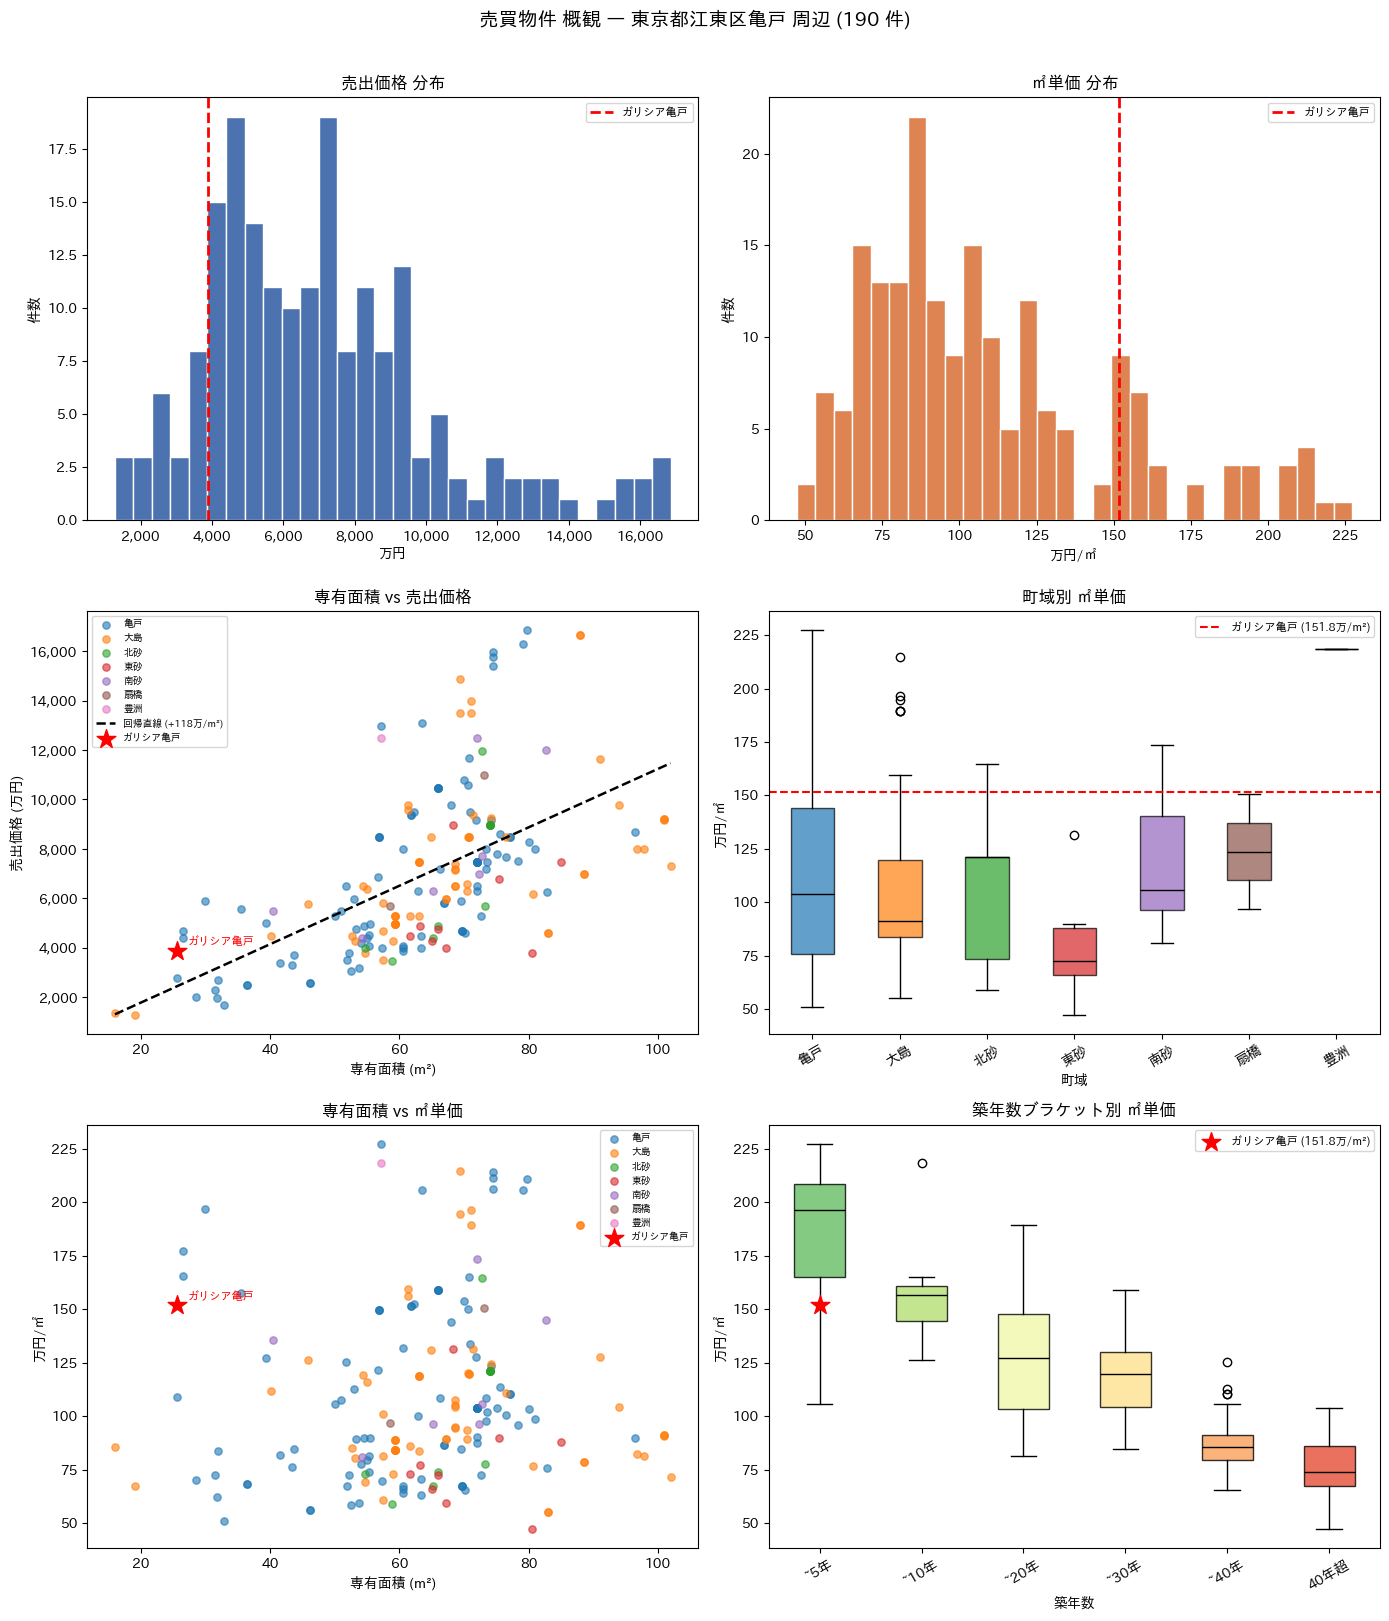

In [12]:

# === 売買データ概観チャート ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import japanize_matplotlib  # noqa: F401  日本語フォントを自動設定

_df = df_sale.dropna(subset=["sale_price_jpy", "exclusive_area_sqm", "price_per_sqm_jpy"]).copy()
_df["sale_price_man"] = _df["sale_price_jpy"].astype(float) / 1e4   # 万円
_df["ppsqm_man"]      = _df["price_per_sqm_jpy"].astype(float) / 1e4
_age_labels = ["~5年", "~10年", "~20年", "~30年", "~40年", "40年超"]

towns      = _df["address_town"].fillna("不明")
palette    = plt.cm.tab10.colors
town_order = towns.value_counts().index.tolist()

# === 検討物件（設定セルの値） ===
_prop_label = PROP_LABEL if "PROP_LABEL" in globals() else None
_prop_area = float(PROP_AREA_SQM) if "PROP_AREA_SQM" in globals() and PROP_AREA_SQM is not None else None
_prop_price_man = (float(PROP_SALE_PRICE_JPY) / 1e4) if "PROP_SALE_PRICE_JPY" in globals() and PROP_SALE_PRICE_JPY else None
_prop_ppsqm_man = (float(PROP_SALE_PRICE_JPY) / _prop_area / 1e4) if ("PROP_SALE_PRICE_JPY" in globals() and PROP_SALE_PRICE_JPY and _prop_area) else None

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle(f"売買物件 概観 — {TARGET_ADDRESS} 周辺 ({len(_df)} 件)", fontsize=14, y=1.01)

# ① 売出価格ヒストグラム
ax = axes[0, 0]
ax.hist(_df["sale_price_man"], bins=30, color="#4C72B0", edgecolor="white")
if _prop_price_man is not None:
    ax.axvline(_prop_price_man, color="red", linewidth=2, linestyle="--", label=_prop_label)
ax.set_title("売出価格 分布")
ax.set_xlabel("万円")
ax.set_ylabel("件数")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
if _prop_price_man is not None:
    ax.legend(fontsize=8)

# ② ㎡単価ヒストグラム
ax = axes[0, 1]
ax.hist(_df["ppsqm_man"], bins=30, color="#DD8452", edgecolor="white")
if _prop_ppsqm_man is not None:
    ax.axvline(_prop_ppsqm_man, color="red", linewidth=2, linestyle="--", label=_prop_label)
ax.set_title("㎡単価 分布")
ax.set_xlabel("万円/㎡")
ax.set_ylabel("件数")
if _prop_ppsqm_man is not None:
    ax.legend(fontsize=8)

# ③ 専有面積 vs 売出価格 + 回帰直線（町域で色分け）
ax = axes[1, 0]
for i, town in enumerate(town_order):
    mask = towns == town
    ax.scatter(
        _df.loc[mask, "exclusive_area_sqm"],
        _df.loc[mask, "sale_price_man"],
        label=town, color=palette[i % len(palette)], alpha=0.6, s=28,
    )
_x     = _df["exclusive_area_sqm"].values.astype(float)
_y     = _df["sale_price_man"].values.astype(float)
_valid = np.isfinite(_x) & np.isfinite(_y)
_coef  = np.polyfit(_x[_valid], _y[_valid], 1)
_xr    = np.linspace(_x[_valid].min(), _x[_valid].max(), 200)
ax.plot(_xr, np.polyval(_coef, _xr), color="black", linewidth=1.8,
        linestyle="--", label=f"回帰直線 ({_coef[0]:+.0f}万/m²)")
if _prop_area is not None and _prop_price_man is not None:
    ax.scatter(_prop_area, _prop_price_man, color="red", s=200, zorder=5, marker="*",
               label=_prop_label)
    ax.annotate(_prop_label, (_prop_area, _prop_price_man),
                textcoords="offset points", xytext=(8, 4), fontsize=8, color="red")
ax.set_title("専有面積 vs 売出価格")
ax.set_xlabel("専有面積 (m²)")
ax.set_ylabel("売出価格 (万円)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=7, loc="upper left")

# ④ 町域別 ㎡単価 ボックスプロット
ax = axes[1, 1]
town_groups = [_df.loc[_df["address_town"] == t, "ppsqm_man"].dropna().values for t in town_order]
bp = ax.boxplot(town_groups, tick_labels=town_order, patch_artist=True, medianprops={"color": "black"})
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
if _prop_ppsqm_man is not None:
    ax.axhline(_prop_ppsqm_man, color="red", linewidth=1.5, linestyle="--",
               label=f"{_prop_label} ({_prop_ppsqm_man:.1f}万/m²)")
ax.set_title("町域別 ㎡単価")
ax.set_xlabel("町域")
ax.set_ylabel("万円/㎡")
ax.tick_params(axis="x", rotation=30)
if _prop_ppsqm_man is not None:
    ax.legend(fontsize=8)

# ⑤ 専有面積 vs ㎡単価（町域で色分け）
ax = axes[2, 0]
for i, town in enumerate(town_order):
    mask = towns == town
    ax.scatter(
        _df.loc[mask, "exclusive_area_sqm"],
        _df.loc[mask, "ppsqm_man"],
        label=town, color=palette[i % len(palette)], alpha=0.6, s=28,
    )
if _prop_area is not None and _prop_ppsqm_man is not None:
    ax.scatter(_prop_area, _prop_ppsqm_man, color="red", s=200, zorder=5, marker="*",
               label=_prop_label)
    ax.annotate(_prop_label, (_prop_area, _prop_ppsqm_man),
                textcoords="offset points", xytext=(8, 4), fontsize=8, color="red")
ax.set_title("専有面積 vs ㎡単価")
ax.set_xlabel("専有面積 (m²)")
ax.set_ylabel("万円/㎡")
ax.legend(fontsize=7, loc="upper right")

# ⑥ 築年数ブラケット別 ㎡単価 ボックスプロット
ax = axes[2, 1]
_valid_brackets = [b for b in _age_labels if (_df["building_age_bracket"] == b).sum() > 0]
_age_groups     = [_df.loc[_df["building_age_bracket"] == b, "ppsqm_man"].dropna().values for b in _valid_brackets]
_age_palette    = plt.cm.RdYlGn(np.linspace(0.8, 0.15, len(_valid_brackets)))
bp2 = ax.boxplot(_age_groups, tick_labels=_valid_brackets, patch_artist=True,
                 medianprops={"color": "black"})
for patch, color in zip(bp2["boxes"], _age_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
# 検討物件は "~5年" ブラケットに対応する位置にマーカー
_prop_bracket_idx = _valid_brackets.index("~5年") + 1 if "~5年" in _valid_brackets else None
if _prop_bracket_idx and _prop_ppsqm_man is not None:
    ax.scatter(_prop_bracket_idx, _prop_ppsqm_man, color="red", s=200, zorder=5, marker="*",
               label=f"{_prop_label} ({_prop_ppsqm_man:.1f}万/m²)")
    ax.legend(fontsize=8)
ax.set_title("築年数ブラケット別 ㎡単価")
ax.set_xlabel("築年数")
ax.set_ylabel("万円/㎡")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [13]:
df_sale[(df_sale["price_per_sqm_jpy"] >= 1_300_000)&(df_sale["building_age_years"] <= 5)].sort_values("price_per_sqm_jpy", ascending=True)
#df_sale#['structure_floors'].value_counts()

,property_name,sale_price_jpy,sale_price_text,address,exclusive_area_sqm,layout,floor_number,structure_floors,built_year_month,structure,building_total_floors,building_basement_floors,price_per_sqm_jpy,address_prefecture,address_municipality,address_town,address_chome,building_age_years,building_age_bracket,detail_url,page_url,source_url,scraped_at,search_address
23,ジオ南砂町,89800000,8980万円,東京都江東区東砂７,68.26,1LDK,8,RC15階建,2022-01,RC,15,<NA>,1315558,東京都,江東区,東砂,7,4,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_786...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
103,リビオシティ南砂町ステーションサイト,54800000,5480万円,東京都江東区南砂７,40.47,1LDK,8,RC13階建,2023-01,RC,13,<NA>,1354089,東京都,江東区,南砂,7,3,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_781...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
178,バウス西大島,119800000,1億1980万円,東京都江東区北砂３,72.76,3LDK,11,RC13階建,2022-07,RC,13,<NA>,1646509,東京都,江東区,北砂,3,4,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_786...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
78,アルテシモ クレルトルテ,43800000,4380万円,東京都江東区亀戸６,26.43,1DK,10,RC13階建,2022-03,RC,13,<NA>,1657208,東京都,江東区,亀戸,6,4,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_789...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
87,アルテシモ クレルトルテ,46800000,4680万円,東京都江東区亀戸６,26.43,1DK,10,RC13階建,2022-03,RC,13,<NA>,1770715,東京都,江東区,亀戸,6,4,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_789...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
26,猿江恩賜公園レジデンス,134800000,1億3480万円,東京都江東区大島２,71.10,3LDK,2,RC14階建,2023-01,RC,14,<NA>,1895921,東京都,江東区,大島,2,3,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
183,猿江恩賜公園レジデンス,135000000,1億3500万円,東京都江東区大島２,69.32,3LDK,13,RC14階建,2023-01,RC,14,<NA>,1947490,東京都,江東区,大島,2,3,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_784...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
184,猿江恩賜公園レジデンス,139800000,1億3980万円,東京都江東区大島２,71.10,3LDK,12,RC14階建,2023-01,RC,14,<NA>,1966245,東京都,江東区,大島,2,3,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_200...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
110,プラウドタワー亀戸クロス ゲートタワー,58800000,5880万円,東京都江東区亀戸６,29.88,1K,6,RC25階地下2階建,2022-01,RC,25,2,1967871,東京都,江東区,亀戸,6,4,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_775...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
29,プラウドタワー亀戸クロス ブライトタワー,162800000,1億6280万円,東京都江東区亀戸６,79.11,3LDK,5,RC25階建,2021-12,RC,25,<NA>,2057894,東京都,江東区,亀戸,6,5,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_201...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸


In [14]:
df_sale[df_sale["building_age_years"] <= 5]
for idx, row in df_sale.groupby('property_name'):
    if len(row) > 3:
        print(f"物件名 '{idx}' で重複: {len(row)} 件")
        display(row[["address", "sale_price_jpy", "exclusive_area_sqm", "built_year_month", 'price_per_sqm_jpy', "detail_url"]])
        display(row['detail_url'].to_list())

物件名 'クレール亀戸' で重複: 5 件


,address,sale_price_jpy,exclusive_area_sqm,built_year_month,price_per_sqm_jpy,detail_url
3,東京都江東区亀戸７,38800000,60.57,1980-11,640581,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_201...
5,東京都江東区亀戸７,40800000,60.57,1980-11,673601,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...
63,東京都江東区亀戸７,30800000,52.52,1980-11,586443,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...
71,東京都江東区亀戸７,39800000,60.57,1980-12,657091,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_200...
73,東京都江東区亀戸７,40800000,55.24,1980-11,738595,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_200...


['https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20161357/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20433493/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20460371/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20037102/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20093324/']

物件名 'コープ野村亀戸' で重複: 4 件


,address,sale_price_jpy,exclusive_area_sqm,built_year_month,price_per_sqm_jpy,detail_url
61,東京都江東区亀戸１,26800000,31.95,1982-06,838811,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_205...
122,東京都江東区亀戸１,64800000,72.00,1982-06,900000,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_203...
135,東京都江東区亀戸１-43-9,74800000,72.00,1982-06,1038889,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_205...
141,東京都江東区亀戸１-43-9,74800000,72.00,1982-06,1038889,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_205...


...

,address,sale_price_jpy,exclusive_area_sqm,built_year_month,price_per_sqm_jpy,detail_url
37,東京都江東区大島９,49800000,59.33,1986-11,839373,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_792...
93,東京都江東区大島９-4-1,49800000,59.33,1986-11,839373,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_791...
101,東京都江東区大島９,52800000,59.33,1986-11,889938,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...
112,東京都江東区大島９,59900000,67.23,1986-11,890971,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_200...


['https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_79219047/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_79179173/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20435869/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20031871/']

物件名 '猿江恩賜公園レジデンス' で重複: 4 件


,address,sale_price_jpy,exclusive_area_sqm,built_year_month,price_per_sqm_jpy,detail_url
26,東京都江東区大島２,134800000,71.10,2023-01,1895921,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...
183,東京都江東区大島２,135000000,69.32,2023-01,1947490,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_784...
184,東京都江東区大島２,139800000,71.10,2023-01,1966245,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_200...
185,東京都江東区大島２-2-20,148800000,69.32,2023-01,2146567,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...


['https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20478412/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_78412276/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20033759/',
 'https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_20419098/']

In [15]:
df_sale

,property_name,sale_price_jpy,sale_price_text,address,exclusive_area_sqm,layout,floor_number,structure_floors,built_year_month,structure,building_total_floors,building_basement_floors,price_per_sqm_jpy,address_prefecture,address_municipality,address_town,address_chome,building_age_years,building_age_bracket,detail_url,page_url,source_url,scraped_at,search_address
0,ヴェラハイツ亀戸,32990000,3299万円,東京都江東区亀戸６,43.35,1LDK,2,SRC9階建一部RC,1978-03,SRC,9,<NA>,761015,東京都,江東区,亀戸,6,48,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_203...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
1,ニューハウス亀戸,34000000,3400万円,東京都江東区亀戸６,41.49,1LDK,4,SRC10階建一部RC,1978-02,SRC,10,<NA>,819475,東京都,江東区,亀戸,6,48,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_200...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
2,ダイアパレス大島,34900000,3490万円,東京都江東区大島７-43-8,57.51,2LDK,2,RC5階建,1978-08,RC,5,<NA>,606851,東京都,江東区,大島,7,48,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_203...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
3,クレール亀戸,38800000,3880万円,東京都江東区亀戸７,60.57,2LDK,2,SRC8階建,1980-11,SRC,8,<NA>,640581,東京都,江東区,亀戸,7,46,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_201...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
4,亀戸マンシヨン,39980000,3998万円,東京都江東区亀戸９,63.28,2LDK,9,SRC14階建,1980-05,SRC,14,<NA>,631795,東京都,江東区,亀戸,9,46,40年超,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_790...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,猿江恩賜公園レジデンス,148800000,1億4880万円,東京都江東区大島２-2-20,69.32,3LDK,14,RC14階建,2023-01,RC,14,<NA>,2146567,東京都,江東区,大島,2,3,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_204...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
186,プラウドタワー亀戸クロス ゲートタワー,157800000,1億5780万円,東京都江東区亀戸６,74.56,3LDK,18,RC25階地下2階建,2021-02,RC,25,2,2116416,東京都,江東区,亀戸,6,5,~5年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_791...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
187,ザ・ミッドランドアベニュー,166600000,1億6660万円,東京都江東区大島３,87.94,3LDK,10,RC14階地下1階建,2012-02,RC,14,1,1894474,東京都,江東区,大島,3,14,~20年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_202...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸
188,ＴＨＥ ＭＩＤＬＡＮＤ ＡＶＥＮＵＥ,166600000,1億6660万円,東京都江東区大島３,87.94,3LDK,10,RC14階地下1階建,2012-02,RC,14,1,1894474,東京都,江東区,大島,3,14,~20年,https://suumo.jp/ms/chuko/tokyo/sc_koto/nc_202...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,https://suumo.jp/jj/bukken/ichiran/JJ012FC001/...,2026-04-05T02:26:27.307933+00:00,東京都江東区亀戸


=== フォーカス条件 ===
  町域: 亀戸
  築年数バケット: ~5年 (検討物件築年数=1年)
  比較対象件数: 11 件

=== 検討物件の相対位置（同条件内） ===
  売出価格: 38,800,000 円 (3,880.0 万円) / パーセンタイル: 9.1%
  ㎡単価:   1,517,997 円/㎡ (151.8 万円/㎡) / パーセンタイル: 9.1%


,指標,平均,中央値,最小,最大
0,売出価格(円),1.127727e+08,1.308000e+08,27800000.0,1.685000e+08
1,㎡単価(円/㎡),1.937217e+06,2.058870e+06,1090196.0,2.273205e+06
2,専有面積(m²),5.558909e+01,6.353000e+01,25.5,7.982000e+01



=== 間取り別サマリ（同条件内） ===


,件数,価格中央値,㎡単価中央値,面積中央値
layout,,,,
3LDK,4,158800000.0,2089592.0,74.56
2LDK,3,130800000.0,2111000.0,63.53
1K,2,43300000.0,1529033.5,27.69
1DK,2,45300000.0,1713961.5,26.43


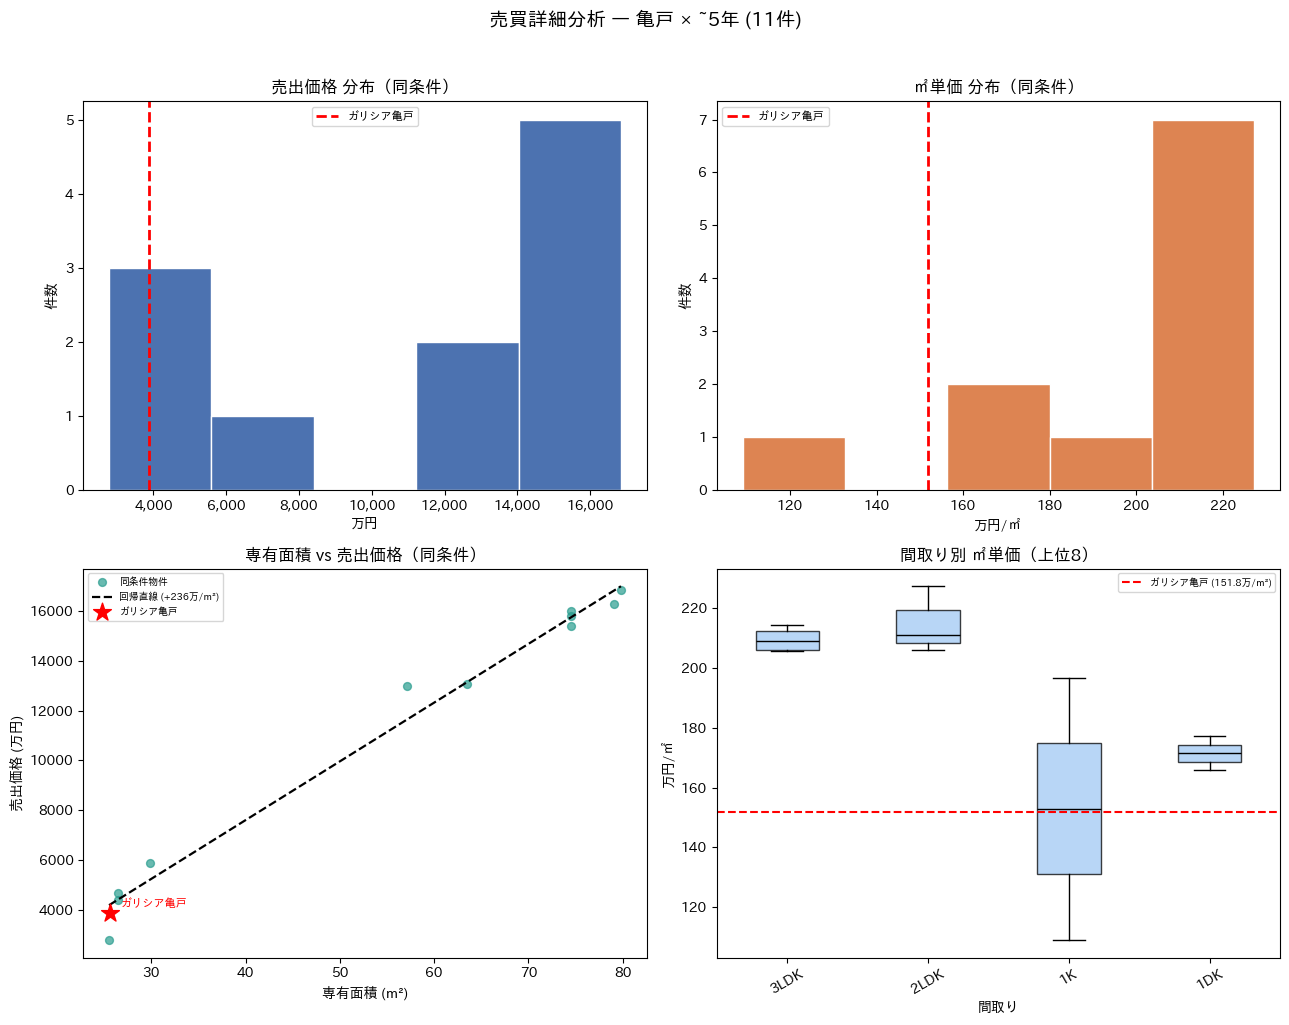

In [16]:
# === 売買詳細分析: 亀戸 × 検討物件と同築年数バケット ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# 検討物件（売買想定）
_prop_label = "ガリシア亀戸"
_prop_area = 25.56
_prop_price_jpy = 38_800_000
_prop_price_man = _prop_price_jpy / 1e4
_prop_ppsqm_jpy = _prop_price_jpy / _prop_area
_prop_ppsqm_man = _prop_ppsqm_jpy / 1e4
_prop_built_year_month = "2025-10"

# 検討物件の築年数バケットを算出
_current_year = datetime.now().year
_prop_built_year = int(str(_prop_built_year_month)[:4])
_prop_age_years = _current_year - _prop_built_year
_age_bins = [0, 5, 10, 20, 30, 40, 200]
_age_labels = ["~5年", "~10年", "~20年", "~30年", "~40年", "40年超"]
_prop_age_bracket = pd.cut(pd.Series([_prop_age_years], dtype="float64"), bins=_age_bins, labels=_age_labels, right=True).iloc[0]

# フィルタ: 亀戸 × 同築年数バケット
_df_base = df_sale.dropna(subset=["sale_price_jpy", "exclusive_area_sqm", "price_per_sqm_jpy"]).copy()
_df_focus = _df_base[
    (_df_base["address_town"] == TARGET_TOWN)
    & (_df_base["building_age_bracket"].astype(str) == str(_prop_age_bracket))
].copy()

if _df_focus.empty:
    print(f"⚠ 条件一致データがありません: 町域={TARGET_TOWN}, 築年数バケット={_prop_age_bracket}")
else:
    _df_focus["sale_price_man"] = _df_focus["sale_price_jpy"].astype(float) / 1e4
    _df_focus["ppsqm_man"] = _df_focus["price_per_sqm_jpy"].astype(float) / 1e4

    # 検討物件の相対位置（パーセンタイル）
    _price_pct = (_df_focus["sale_price_jpy"] <= _prop_price_jpy).mean() * 100
    _ppsqm_pct = (_df_focus["price_per_sqm_jpy"] <= _prop_ppsqm_jpy).mean() * 100

    print("=== フォーカス条件 ===")
    print(f"  町域: {TARGET_TOWN}")
    print(f"  築年数バケット: {_prop_age_bracket} (検討物件築年数={_prop_age_years}年)")
    print(f"  比較対象件数: {len(_df_focus)} 件")
    print("\n=== 検討物件の相対位置（同条件内） ===")
    print(f"  売出価格: {_prop_price_jpy:,.0f} 円 ({_prop_price_man:,.1f} 万円) / パーセンタイル: {_price_pct:.1f}%")
    print(f"  ㎡単価:   {_prop_ppsqm_jpy:,.0f} 円/㎡ ({_prop_ppsqm_man:,.1f} 万円/㎡) / パーセンタイル: {_ppsqm_pct:.1f}%")

    # 要約統計
    _summary = pd.DataFrame({
        "指標": ["売出価格(円)", "㎡単価(円/㎡)", "専有面積(m²)"],
        "平均": [
            _df_focus["sale_price_jpy"].mean(),
            _df_focus["price_per_sqm_jpy"].mean(),
            _df_focus["exclusive_area_sqm"].mean(),
        ],
        "中央値": [
            _df_focus["sale_price_jpy"].median(),
            _df_focus["price_per_sqm_jpy"].median(),
            _df_focus["exclusive_area_sqm"].median(),
        ],
        "最小": [
            _df_focus["sale_price_jpy"].min(),
            _df_focus["price_per_sqm_jpy"].min(),
            _df_focus["exclusive_area_sqm"].min(),
        ],
        "最大": [
            _df_focus["sale_price_jpy"].max(),
            _df_focus["price_per_sqm_jpy"].max(),
            _df_focus["exclusive_area_sqm"].max(),
        ],
    })
    display(_summary)

    # 間取り別比較（件数があるもののみ）
    _layout_stats = (
        _df_focus.dropna(subset=["layout"])
        .groupby("layout")
        .agg(
            count=("layout", "size"),
            price_median=("sale_price_jpy", "median"),
            ppsqm_median=("price_per_sqm_jpy", "median"),
            area_median=("exclusive_area_sqm", "median"),
        )
        .rename(columns={
            "count": "件数",
            "price_median": "価格中央値",
            "ppsqm_median": "㎡単価中央値",
            "area_median": "面積中央値",
        })
        .sort_values("件数", ascending=False)
    )
    if not _layout_stats.empty:
        print("\n=== 間取り別サマリ（同条件内） ===")
        display(_layout_stats)

    # 詳細チャート
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(f"売買詳細分析 — {TARGET_TOWN} × {_prop_age_bracket} ({len(_df_focus)}件)", fontsize=14, y=1.02)

    # 1) 売出価格分布
    ax = axes[0, 0]
    ax.hist(_df_focus["sale_price_man"], bins=min(20, max(5, len(_df_focus)//2)), color="#4C72B0", edgecolor="white")
    ax.axvline(_prop_price_man, color="red", linestyle="--", linewidth=2, label=_prop_label)
    ax.set_title("売出価格 分布（同条件）")
    ax.set_xlabel("万円")
    ax.set_ylabel("件数")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(fontsize=8)

    # 2) ㎡単価分布
    ax = axes[0, 1]
    ax.hist(_df_focus["ppsqm_man"], bins=min(20, max(5, len(_df_focus)//2)), color="#DD8452", edgecolor="white")
    ax.axvline(_prop_ppsqm_man, color="red", linestyle="--", linewidth=2, label=_prop_label)
    ax.set_title("㎡単価 分布（同条件）")
    ax.set_xlabel("万円/㎡")
    ax.set_ylabel("件数")
    ax.legend(fontsize=8)

    # 3) 専有面積 vs 売出価格
    ax = axes[1, 0]
    ax.scatter(_df_focus["exclusive_area_sqm"], _df_focus["sale_price_man"], alpha=0.7, s=32, color="#2A9D8F", label="同条件物件")
    _x = _df_focus["exclusive_area_sqm"].values.astype(float)
    _y = _df_focus["sale_price_man"].values.astype(float)
    _valid = np.isfinite(_x) & np.isfinite(_y)
    if _valid.sum() >= 2:
        _coef = np.polyfit(_x[_valid], _y[_valid], 1)
        _xr = np.linspace(_x[_valid].min(), _x[_valid].max(), 200)
        ax.plot(_xr, np.polyval(_coef, _xr), color="black", linewidth=1.6, linestyle="--", label=f"回帰直線 ({_coef[0]:+.0f}万/m²)")
    ax.scatter(_prop_area, _prop_price_man, color="red", s=180, marker="*", zorder=5, label=_prop_label)
    ax.annotate(_prop_label, (_prop_area, _prop_price_man), textcoords="offset points", xytext=(8, 4), fontsize=8, color="red")
    ax.set_title("専有面積 vs 売出価格（同条件）")
    ax.set_xlabel("専有面積 (m²)")
    ax.set_ylabel("売出価格 (万円)")
    ax.legend(fontsize=7)

    # 4) 間取り別 ㎡単価ボックス
    ax = axes[1, 1]
    _top_layouts = _df_focus["layout"].fillna("不明").value_counts().head(8).index.tolist()
    _groups = [_df_focus.loc[_df_focus["layout"].fillna("不明") == l, "ppsqm_man"].dropna().values for l in _top_layouts]
    if _groups and any(len(g) > 0 for g in _groups):
        bp = ax.boxplot(_groups, tick_labels=_top_layouts, patch_artist=True, medianprops={"color": "black"})
        for patch in bp["boxes"]:
            patch.set_facecolor("#A1C9F4")
            patch.set_alpha(0.75)
        ax.axhline(_prop_ppsqm_man, color="red", linewidth=1.5, linestyle="--", label=f"{_prop_label} ({_prop_ppsqm_man:.1f}万/m²)")
        ax.legend(fontsize=7)
    ax.set_title("間取り別 ㎡単価（上位8）")
    ax.set_xlabel("間取り")
    ax.set_ylabel("万円/㎡")
    ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


---
## 1-2. SUUMO 賃貸募集中物件データの収集

### 処理フロー
1. SUUMO 賃貸一覧ページをページネーションで取得
2. 各物件カードから賃料・管理費・敷金・礼金等を抽出
3. 住所マッチングでフィルタ → DataFrame 化

### 確認ポイント
- 取得件数が妥当か
- 賃料の分布が地域相場と合っているか
- 敷金・礼金が「-」の場合に 0 として処理されているか

In [17]:
# === 賃貸向け: 築年数表記を built_year_month に補完 ===
# 例: "築5年" / "築3年2ヶ月" / "築1年未満" / "新築" を YYYY-MM に変換
if "_parse_built_year_month_base" not in globals():
    _parse_built_year_month_base = parse_built_year_month


def parse_built_year_month(text: str) -> Optional[str]:
    base = _parse_built_year_month_base(text)
    if base:
        return base
    if not text:
        return None

    s = unicodedata.normalize("NFKC", str(text)).strip()
    ref = pd.Timestamp(datetime.now().date()).replace(day=1)

    # 新築 / 築1年未満
    if re.search(r"新築|築\s*1\s*年未満", s):
        return ref.strftime("%Y-%m")

    # 築N年Mヶ月 / 築N年 / 築Mヶ月
    m = re.search(r"築\s*(?:(\d+)\s*年)?\s*(?:(\d+)\s*(?:ヶ月|か月|カ月|ヵ月))?", s)
    if m and (m.group(1) or m.group(2)):
        years = int(m.group(1) or 0)
        months = int(m.group(2) or 0)
        built = ref - pd.DateOffset(months=years * 12 + months)
        return built.strftime("%Y-%m")

    return None


print("賃貸向け築年月パーサーを有効化しました")

賃貸向け築年月パーサーを有効化しました


In [18]:
# === 賃貸向け: 詳細ページから所在階を補完 ===
def fetch_suumo_rent_detail(url: str) -> Dict[str, Any]:
    """SUUMO 賃貸詳細ページから所在階を取得する"""
    if not url:
        return {"floor_number": None}

    html, status, _ = fetch_page(url)
    if not html:
        logger.debug(f"賃貸詳細ページ取得失敗: {url} (status={status})")
        return {"floor_number": None}

    soup = parse_html(html)
    floor_number = None

    # 1) テーブルの th/td から抽出
    for th in soup.select("th"):
        label = th.get_text(strip=True).replace("ヒント", "").strip()
        td = th.find_next_sibling("td")
        if not td:
            continue
        val = td.get_text(strip=True)
        if label in ("所在階", "階/階建", "所在階/階数"):
            floor_number = parse_floor_number(val)
            if floor_number is not None:
                return {"floor_number": floor_number}

    # 2) ページ全体テキストからフォールバック抽出
    text = soup.get_text(" ", strip=True)
    patterns = [
        r"所在階\s*[:：]?\s*(地下\s*\d+\s*階|\d+\s*階)",
        r"(地下\s*\d+\s*階)\s*/\s*\d+\s*階建",
        r"(\d+\s*階)\s*/\s*\d+\s*階建",
    ]
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            floor_number = parse_floor_number(m.group(1))
            if floor_number is not None:
                return {"floor_number": floor_number}

    return {"floor_number": None}


print("賃貸詳細ページ補完ヘルパーを有効化しました")

賃貸詳細ページ補完ヘルパーを有効化しました


In [19]:
# === SUUMO 賃貸: 1ページのパーサー ===

def _parse_rent_fee(text: str) -> Optional[int]:
    """賃料・管理費等を円に変換。'-' は 0、'1ヶ月' 等は None (後で賃料から計算)"""
    if not text:
        return None
    s = unicodedata.normalize("NFKC", text).strip()
    if s in ("-", "ー", "−", "なし", "無"):
        return 0
    # 「1ヶ月」等の月数表記はここでは None を返す（後処理で対応）
    if re.search(r"ヶ月|ヵ月|カ月|か月", s):
        return None  # 月数として後で処理
    return parse_japanese_price(s)


def _parse_months_fee(text: str) -> Optional[float]:
    """'1ヶ月' → 1.0 のように月数を返す"""
    if not text:
        return None
    s = unicodedata.normalize("NFKC", text).strip()
    if s in ("-", "ー", "−", "なし", "無"):
        return 0.0
    m = re.search(r"([\d.]+)\s*(?:ヶ月|ヵ月|カ月|か月)", s)
    if m:
        return float(m.group(1))
    return None


def parse_suumo_rent_page(html: str, page_url: str) -> List[Dict[str, Any]]:
    """
    SUUMO 賃貸一覧ページ 1 ページ分をパースし、物件リスト(dict)を返す。
    """
    soup = parse_html(html)
    results = []

    # 物件カードのセレクタ候補
    card_selectors = [
        "div.cassetteitem",
        "div.property_unit",
        "div.cassette_item",
        "article.cassetteitem",
    ]

    cards = []
    for sel in card_selectors:
        cards = soup.select(sel)
        if cards:
            logger.info(f"賃貸カードセレクタ '{sel}' で {len(cards)} 件検出")
            break

    if not cards:
        logger.warning(f"賃貸物件カードが見つかりません: {page_url}")
        return results

    for idx, card in enumerate(cards):
        try:
            # 物件名（建物情報部分）
            name = safe_extract(card, [
                "div.cassetteitem_content-title",
                "span.cassetteitem_content-title",
                "div.property_unit-title a",
                "h2.property_unit-title a",
            ])

            # 住所
            address = safe_extract(card, [
                "li.cassetteitem_detail-col1",
                "div.cassetteitem_detail-col1",
                "dd.property_unit-body_address",
            ])

            # 築年数・階数
            detail_cols = card.select(
                "li.cassetteitem_detail-col2 div, "
                "div.cassetteitem_detail-col2 div, "
                "li.cassetteitem_detail-col3 div, "
                "div.cassetteitem_detail-col3 div"
            )
            built_text = None
            for dc in detail_cols:
                t = dc.get_text(strip=True)
                if "築" in t or ("年" in t and "月" in t):
                    built_text = t
                    break
            if not built_text:
                built_text = safe_extract(card, [
                    "li.cassetteitem_detail-col2",
                    "div.cassetteitem_detail-col2",
                ])

            # SUUMO 賃貸は 1 建物に複数部屋がある構造
            room_rows = card.select(
                "table.cassetteitem_other tbody tr, "
                "div.cassetteitem_other tbody tr"
            )
            if not room_rows:
                # 部屋行がない場合は建物全体を 1 件として扱う
                room_rows = [card]

            for room in room_rows:
                try:
                    # 賃料
                    rent_text = safe_extract(room, [
                        "span.cassetteitem_other-emphasis",
                        "td.cassetteitem_other-emphasis span",
                        "span.cassetteitem_price--rent",
                        "li:nth-child(1) span.cassetteitem_other-emphasis",
                    ])

                    # 管理費
                    admin_text = safe_extract(room, [
                        "span.cassetteitem_price--administration",
                        "td:nth-child(2) span",
                    ])

                    # 敷金
                    deposit_text = safe_extract(room, [
                        "span.cassetteitem_price--deposit",
                        "td:nth-child(3) span",
                    ])

                    # 礼金
                    key_money_text = safe_extract(room, [
                        "span.cassetteitem_price--gratuity",
                        "td:nth-child(4) span",
                    ])

                    # 間取り
                    room_layout = safe_extract(room, [
                        "span.cassetteitem_madori",
                        "td:nth-child(5) span",
                    ])

                    # 面積
                    room_area_text = safe_extract(room, [
                        "span.cassetteitem_menseki",
                        "td:nth-child(6) span",
                    ])

                    # 所在階（部屋行）
                    floor_text = safe_extract(room, [
                        "span.cassetteitem_other-floor",
                        "span.cassetteitem_floor",
                        "td:nth-child(7) span",
                    ])
                    if not floor_text:
                        room_text = room.get_text(" ", strip=True)
                        m_floor = re.search(r"(地下\s*\d+\s*階|\d+\s*階)", room_text)
                        floor_text = m_floor.group(1) if m_floor else None

                    # 詳細URL
                    detail_url = safe_extract(room, [
                        "td.ui-text--midium a",
                        "a[href*='chintai/jnc']",
                        "a[href*='/bc_']",
                    ], attribute="href")
                    if detail_url and not detail_url.startswith("http"):
                        detail_url = urljoin("https://suumo.jp", detail_url)

                    # 敷金・礼金: 月数 or 金額
                    rent_jpy = _parse_rent_fee(rent_text)
                    deposit_jpy = _parse_rent_fee(deposit_text)
                    key_money_jpy = _parse_rent_fee(key_money_text)

                    # 月数表記の場合、賃料から計算
                    if deposit_jpy is None and rent_jpy and deposit_text:
                        months = _parse_months_fee(deposit_text)
                        if months is not None:
                            deposit_jpy = int(rent_jpy * months)
                    if key_money_jpy is None and rent_jpy and key_money_text:
                        months = _parse_months_fee(key_money_text)
                        if months is not None:
                            key_money_jpy = int(rent_jpy * months)

                    results.append({
                        "property_name": name,
                        "rent_jpy": rent_jpy,
                        "rent_text": rent_text,
                        "maintenance_fee_jpy": _parse_rent_fee(admin_text),
                        "deposit_jpy": deposit_jpy,
                        "deposit_text": deposit_text,
                        "key_money_jpy": key_money_jpy,
                        "key_money_text": key_money_text,
                        "address": address,
                        "exclusive_area_sqm": parse_area(room_area_text),
                        "layout": room_layout,
                        "floor_number": parse_floor_number(floor_text) if floor_text else None,
                        "built_year_month": parse_built_year_month(built_text) if built_text else None,
                        "detail_url": detail_url,
                    })

                except Exception as e:
                    logger.warning(f"賃貸部屋パース失敗 (物件#{idx}): {e}")
                    continue

        except Exception as e:
            logger.warning(f"賃貸物件 #{idx} のパースに失敗 ({page_url}): {e}")
            continue

    return results

In [20]:

# === SUUMO 賃貸: ページネーション付き収集 ===

def collect_suumo_rent_listings(
    base_url: str,
    max_pages: Optional[int] = MAX_PAGES_RENT,
    enable_address_filter: bool = RENT_ENABLE_ADDRESS_FILTER,
    enable_detail_enrichment: bool = RENT_ENABLE_DETAIL_ENRICHMENT,
) -> pd.DataFrame:
    """
    SUUMO 賃貸一覧を複数ページにわたって収集し DataFrame で返す。
    賃貸は ?page=N のクエリパラメータ形式。
    """
    all_records: List[Dict] = []

    # 1ページ目を先に取得し、max_pages=None の場合はページリンク/総件数からページ数を自動推定
    first_page_url = base_url if "?" in base_url else f"{base_url}?page=1"
    html_first, status_first, final_first = fetch_page(first_page_url)
    if not html_first:
        logger.warning(f"賃貸1ページ目の取得失敗 (status={status_first})")
        return pd.DataFrame()

    if max_pages is None:
        # まずはページネーションリンクから最大ページを推定（こちらの方が安定）
        _linked = [int(x) for x in re.findall(r"[?&]page=(\d+)", html_first)]
        _max_linked_page = max(_linked) if _linked else None

        if _max_linked_page and _max_linked_page >= 1:
            max_pages = _max_linked_page
            logger.info(f"賃貸ページ数を自動算出: リンク最大ページ={max_pages}")
        else:
            # フォールバック: "17,937件" などから総件数を推定（サイト表示が紛らわしい場合がある）
            _hits = [int(x.replace(",", "")) for x in re.findall(r"([\d,]+)\s*件", html_first)]
            _total_hits = max(_hits) if _hits else None
            if _total_hits:
                max_pages = int(np.ceil(_total_hits / RENT_PAGE_SIZE))
                logger.info(
                    f"賃貸ページ数を自動算出: 総件数={_total_hits:,}件, "
                    f"{RENT_PAGE_SIZE}件/ページ -> {max_pages}ページ"
                )
            else:
                max_pages = 1
                logger.warning("賃貸総件数をHTMLから取得できなかったため max_pages=1 で実行")

    for page_num in tqdm(range(1, max_pages + 1), desc="賃貸ページ取得"):
        if page_num == 1:
            html, status, final_url = html_first, status_first, final_first
        else:
            if "?" in base_url:
                page_url = f"{base_url}&page={page_num}"
            else:
                page_url = f"{base_url}?page={page_num}"
            html, status, final_url = fetch_page(page_url)

        if not html:
            logger.warning(f"賃貸ページ {page_num} の取得失敗 (status={status})")
            continue

        records = parse_suumo_rent_page(html, final_url)
        if not records:
            logger.info(f"賃貸ページ {page_num}: 物件 0 件 -> ページネーション終了")
            break

        for r in records:
            r["page_url"] = final_url
        all_records.extend(records)
        logger.info(f"賃貸ページ {page_num}: {len(records)} 件取得 (累計 {len(all_records)} 件)")

    if not all_records:
        logger.warning("賃貸物件が 0 件でした。URL またはセレクタを確認してください。")
        return pd.DataFrame()

    df = pd.DataFrame(all_records)
    df = add_audit_columns(df, base_url, TARGET_ADDRESS)

    # 住所マッチングフィルタ（URLが町域固定の場合は通常不要）
    if enable_address_filter:
        before_count = len(df)
        df["address_matched"] = df["address"].apply(
            lambda a: match_address(a, TARGET_ADDRESS, TARGET_TOWN) if a else False
        )
        df = df[df["address_matched"]].drop(columns=["address_matched"]).copy()
        logger.info(
            f"賃貸: 全 {before_count} 件 -> 住所マッチ {len(df)} 件 "
            f"(除外 {before_count - len(df)} 件)"
        )
    else:
        logger.info(f"賃貸: 住所フィルタをスキップ (件数 {len(df)} 件)")

    # 間取りを正規化
    if "layout" in df.columns:
        df["layout"] = df["layout"].apply(normalize_layout)

    # 詳細ページから所在階を補完（全件収集では重いため任意）
    if enable_detail_enrichment and "detail_url" in df.columns:
        logger.info(f"賃貸詳細ページ取得開始: {len(df)} 件")
        _detail_records = []
        for _url in tqdm(df["detail_url"].tolist(), desc="賃貸詳細ページ取得"):
            _detail_records.append(fetch_suumo_rent_detail(_url))
        _detail_df = pd.DataFrame(_detail_records, index=df.index)

        if "floor_number" not in df.columns:
            df["floor_number"] = pd.Series([pd.NA] * len(df), index=df.index)
        _list_floor = pd.to_numeric(df["floor_number"], errors="coerce")
        _detail_floor = pd.to_numeric(_detail_df["floor_number"], errors="coerce")
        df["floor_number"] = _list_floor.where(_list_floor.notna(), _detail_floor)

    # 型変換
    int_cols = ["rent_jpy", "maintenance_fee_jpy", "deposit_jpy", "key_money_jpy", "floor_number"]
    for col in int_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    if "exclusive_area_sqm" in df.columns:
        df["exclusive_area_sqm"] = pd.to_numeric(df["exclusive_area_sqm"], errors="coerce")

    # 賃料㎡単価を計算
    if "rent_jpy" in df.columns and "exclusive_area_sqm" in df.columns:
        df["rent_per_sqm_jpy"] = (
            df["rent_jpy"].astype("float64") / df["exclusive_area_sqm"]
        ).round(0).astype("Int64")

    # 住所分解: 都道府県・市区町村・町域・丁目
    df = add_address_components(df)

    # 築年数・築年数ブラケットを計算
    import datetime as _dt
    _current_year = _dt.date.today().year
    if "built_year_month" in df.columns:
        df["building_age_years"] = (
            _current_year
            - df["built_year_month"].str.extract(r"^(\d{4})")[0].astype(float)
        ).round(0).astype("Int64")
        _age_bins   = [0, 5, 10, 20, 30, 40, 200]
        _age_labels = ["~5年", "~10年", "~20年", "~30年", "~40年", "40年超"]
        df["building_age_bracket"] = pd.cut(
            df["building_age_years"].astype(float),
            bins=_age_bins, labels=_age_labels, right=True
        )

    # URL系カラムを右端に移動
    _url_cols = [c for c in ["detail_url", "page_url", "source_url", "scraped_at", "search_address"] if c in df.columns]
    _other_cols = [c for c in df.columns if c not in _url_cols]
    df = df[_other_cols + _url_cols]

    return df.reset_index(drop=True)

In [21]:
# === 実行時チューニング（全ページ取得の高速化） ===
# 1&2対応: 全ページ収集 + 待機時間短縮
REQUEST_SLEEP_MIN = 0.2
REQUEST_SLEEP_MAX = 0.6

# 念のため明示
MAX_PAGES_RENT = None
RENT_ENABLE_ADDRESS_FILTER = False
RENT_ENABLE_DETAIL_ENRICHMENT = False

print("賃貸収集チューニングを適用しました")
print(f"REQUEST_SLEEP_MIN={REQUEST_SLEEP_MIN}, REQUEST_SLEEP_MAX={REQUEST_SLEEP_MAX}")
print(f"MAX_PAGES_RENT={MAX_PAGES_RENT} (None=自動)")

賃貸収集チューニングを適用しました
REQUEST_SLEEP_MIN=0.2, REQUEST_SLEEP_MAX=0.6
MAX_PAGES_RENT=None (None=自動)


In [22]:
# === 賃貸ページ数の実測確認（1ページ目HTML基準） ===
html_p1, st_p1, _ = fetch_page(f"{SUUMO_RENT_URL}?page=1")
if html_p1:
    linked_pages = [int(x) for x in re.findall(r"[?&]page=(\d+)", html_p1)]
    max_linked_page = max(linked_pages) if linked_pages else 1
    count_tokens = [int(x.replace(',', '')) for x in re.findall(r"([\d,]+)\s*件", html_p1)]
    print(f"status={st_p1}")
    print(f"リンク上の最大ページ: {max_linked_page}")
    print(f"件数トークン最大値: {max(count_tokens) if count_tokens else 'N/A'}")
else:
    print(f"1ページ目取得失敗: status={st_p1}")

status=200
リンク上の最大ページ: 30
件数トークン最大値: 15390


In [23]:
# === 賃貸データ収集: 実行 & プレビュー ===
df_rent = collect_suumo_rent_listings(SUUMO_RENT_URL, MAX_PAGES_RENT)

print(f"\n=== 賃貸データ概要 ===")
print(f"件数: {len(df_rent)}")
if not df_rent.empty:
    print(f"\nカラム一覧:\n{df_rent.dtypes.to_string()}")
    print(f"\n--- 基本統計 ---")
    if "rent_jpy" in df_rent.columns:
        rents = df_rent["rent_jpy"].dropna()
        if not rents.empty:
            print(f"  賃料 平均: {rents.mean():,.0f} 円")
            print(f"  賃料 中央: {rents.median():,.0f} 円")
            print(f"  賃料 範囲: {rents.min():,.0f} - {rents.max():,.0f} 円")
    if "maintenance_fee_jpy" in df_rent.columns:
        fees = df_rent["maintenance_fee_jpy"].dropna()
        if not fees.empty:
            print(f"  管理費 平均: {fees.mean():,.0f} 円")
    for col_name, label in [("deposit_jpy", "敷金"), ("key_money_jpy", "礼金")]:
        if col_name in df_rent.columns:
            vals = df_rent[col_name].dropna()
            zero_pct = (vals == 0).mean() * 100 if not vals.empty else 0
            print(f"  {label} ゼロ率: {zero_pct:.1f}%")

    if ENABLE_DEBUG_PREVIEW:
        display(df_rent.head(10))
else:
    print("⚠ データが取得できませんでした。URL / セレクタを確認してください。")

2026-04-05 11:38:46 [INFO] 賃貸ページ数を自動算出: リンク最大ページ=30


賃貸ページ取得:   0%|          | 0/30 [00:00<?, ?it/s]

2026-04-05 11:38:46 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:38:46 [INFO] 賃貸ページ 1: 25 件取得 (累計 25 件)
2026-04-05 11:38:49 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:38:49 [INFO] 賃貸ページ 2: 22 件取得 (累計 47 件)
2026-04-05 11:38:52 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:38:52 [INFO] 賃貸ページ 3: 23 件取得 (累計 70 件)
2026-04-05 11:38:54 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:38:54 [INFO] 賃貸ページ 4: 25 件取得 (累計 95 件)
2026-04-05 11:38:58 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:38:58 [INFO] 賃貸ページ 5: 33 件取得 (累計 128 件)
2026-04-05 11:39:00 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:39:00 [INFO] 賃貸ページ 6: 29 件取得 (累計 157 件)
2026-04-05 11:39:02 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:39:02 [INFO] 賃貸ページ 7: 42 件取得 (累計 199 件)
2026-04-05 11:39:04 [INFO] 賃貸カードセレクタ 'div.cassetteitem' で 20 件検出
2026-04-05 11:39:04 [INFO] 賃貸ページ 8: 36 件取得 (累計 235 件)
2026-04-05 11:39:06 [INFO] 賃貸カードセレクタ 'div.cassetteit


=== 賃貸データ概要 ===
件数: 1511

カラム一覧:
property_name             object
rent_jpy                   Int64
rent_text                 object
maintenance_fee_jpy        Int64
deposit_jpy                Int64
deposit_text              object
key_money_jpy              Int64
key_money_text            object
address                   object
exclusive_area_sqm       float64
layout                    object
floor_number               Int64
built_year_month          object
rent_per_sqm_jpy           Int64
address_prefecture        object
address_municipality      object
address_town              object
address_chome              int64
building_age_years         Int64
building_age_bracket    category
detail_url                object
page_url                  object
source_url                object
scraped_at                object
search_address            object

--- 基本統計 ---
  賃料 平均: 132,106 円
  賃料 中央: 123,000 円
  賃料 範囲: 40,000 - 400,000 円
  管理費 平均: 10,661 円
  敷金 ゼロ率: 50.8%
  礼金 ゼロ率: 39.6%


,property_name,rent_jpy,rent_text,maintenance_fee_jpy,deposit_jpy,deposit_text,key_money_jpy,key_money_text,address,exclusive_area_sqm,layout,floor_number,built_year_month,rent_per_sqm_jpy,address_prefecture,address_municipality,address_town,address_chome,building_age_years,building_age_bracket,detail_url,page_url,source_url,scraped_at,search_address
0,クローバー亀戸,95000,9.5万円,0,95000,9.5万円,95000,9.5万円,東京都江東区亀戸７,31.11,2K,2,1963-04,3054,東京都,江東区,亀戸,7,63,40年超,https://suumo.jp/chintai/jnc_000105857661/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
1,鳥海荘,46000,4.6万円,0,46000,4.6万円,0,-,東京都江東区亀戸３,10.81,1K,<NA>,1963-04,4255,東京都,江東区,亀戸,3,63,40年超,https://suumo.jp/chintai/jnc_000105779010/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
2,高庭ビル,45000,4.5万円,0,45000,4.5万円,0,-,東京都江東区亀戸７,20.00,1K,3,1960-04,2250,東京都,江東区,亀戸,7,66,40年超,https://suumo.jp/chintai/jnc_000080694491/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
3,ＪＲ総武線 亀戸駅 3階建 築66年,45000,4.5万円,0,45000,4.5万円,0,-,東京都江東区亀戸７,20.00,1K,3,1960-04,2250,東京都,江東区,亀戸,7,66,40年超,https://suumo.jp/chintai/jnc_000080356139/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
4,今田ビル,69000,6.9万円,0,69000,6.9万円,69000,6.9万円,東京都江東区亀戸３,26.08,2K,4,1972-04,2646,東京都,江東区,亀戸,3,54,40年超,https://suumo.jp/chintai/jnc_000094908888/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
5,今田ビル,75000,7.5万円,0,75000,7.5万円,75000,7.5万円,東京都江東区亀戸３,32.00,2DK,<NA>,1972-04,2344,東京都,江東区,亀戸,3,54,40年超,https://suumo.jp/chintai/jnc_000081950485/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
6,今田ビル,75000,7.5万円,0,75000,7.5万円,75000,7.5万円,東京都江東区亀戸３,32.00,2DK,<NA>,1972-04,2344,東京都,江東区,亀戸,3,54,40年超,https://suumo.jp/chintai/jnc_000099977509/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
7,ＪＲ総武線 亀戸駅 6階建 築54年,75000,7.5万円,0,75000,7.5万円,75000,7.5万円,東京都江東区亀戸３,32.00,2DK,2,1972-04,2344,東京都,江東区,亀戸,3,54,40年超,https://suumo.jp/chintai/jnc_000106161936/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
8,白田荘,50000,5万円,2000,50000,5万円,50000,5万円,東京都江東区亀戸７,23.00,2K,<NA>,1968-04,2174,東京都,江東区,亀戸,7,58,40年超,https://suumo.jp/chintai/jnc_000051409363/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
9,白田荘,50000,5万円,2000,50000,5万円,50000,5万円,東京都江東区亀戸７,23.00,2K,<NA>,1968-04,2174,東京都,江東区,亀戸,7,58,40年超,https://suumo.jp/chintai/jnc_000096422349/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸


In [24]:
# === 全ページ取得の実行確認 ===
print("=== ページカバレッジ確認 ===")
if "page_url" in df_rent.columns:
    n_pages = df_rent["page_url"].dropna().nunique()
    print(f"df_rent上のユニーク page_url 数: {n_pages}")
    _samples = sorted(df_rent["page_url"].dropna().unique())
    print("先頭3ページ:", _samples[:3])
    print("末尾3ページ:", _samples[-3:])

print("\n=== 重複除去の影響確認（同一キー重複） ===")
keys = [c for c in ["property_name", "rent_jpy", "layout", "floor_number"] if c in df_rent.columns]
if keys:
    dup_after = df_rent.duplicated(subset=keys).sum()
    print(f"重複キー: {keys}")
    print(f"重複件数(除去後): {dup_after}")
print(f"最終件数: {len(df_rent)}")

=== ページカバレッジ確認 ===
df_rent上のユニーク page_url 数: 30
先頭3ページ: ['https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/?page=1', 'https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/?page=10', 'https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/?page=11']
末尾3ページ: ['https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/?page=7', 'https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/?page=8', 'https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/?page=9']

=== 重複除去の影響確認（同一キー重複） ===
重複キー: ['property_name', 'rent_jpy', 'layout', 'floor_number']
重複件数(除去後): 136
最終件数: 1511


In [25]:
# === URL整合性チェック（最小出力） ===
def _first_non_null(series: pd.Series):
    try:
        return series.dropna().iloc[0]
    except Exception:
        return None

sale_sample_url = _first_non_null(df_sale["page_url"]) if "df_sale" in globals() and not df_sale.empty else None
rent_sample_url = _first_non_null(df_rent["page_url"]) if "df_rent" in globals() and not df_rent.empty else None

print("sale page_url sample:", sale_sample_url)
print("rent page_url sample:", rent_sample_url)
print("sale contains sc=13109:", ("sc=13109" in str(sale_sample_url)) if sale_sample_url else None)
print("rent contains sc_shinagawa:", ("sc_shinagawa" in str(rent_sample_url)) if rent_sample_url else None)
if "df_rent" in globals() and not df_rent.empty:
    print("rent unique page_url:", df_rent["page_url"].nunique())

sale page_url sample: https://suumo.jp/jj/bukken/ichiran/JJ012FC001/?ar=030&bs=011&ta=13&sc=13108&cn=9999999&kb=1&kt=9999999&mb=0&mt=9999999&et=9999999&fw2=%E4%BA%80%E6%88%B8&page=1
rent page_url sample: https://suumo.jp/chintai/tokyo/sc_koto/oz_13108009/?page=1
sale contains sc=13109: False
rent contains sc_shinagawa: False
rent unique page_url: 30


In [26]:
# === 賃貸: 築年月・所在階補完の確認 ===
if "built_year_month" in df_rent.columns:
    _n = len(df_rent)
    _ok = df_rent["built_year_month"].notna().sum()
    print(f"built_year_month 取得率: {_ok}/{_n} ({(_ok/_n*100 if _n else 0):.1f}%)")

if "floor_number" in df_rent.columns:
    _n = len(df_rent)
    _ok_floor = df_rent["floor_number"].notna().sum()
    print(f"floor_number 取得率: {_ok_floor}/{_n} ({(_ok_floor/_n*100 if _n else 0):.1f}%)")

print("\nサンプル:")
display(df_rent[["property_name", "layout", "floor_number", "built_year_month", "building_age_years", "rent_jpy"]].head(20))

built_year_month 取得率: 1511/1511 (100.0%)
floor_number 取得率: 815/1511 (53.9%)

サンプル:


,property_name,layout,floor_number,built_year_month,building_age_years,rent_jpy
0,クローバー亀戸,2K,2,1963-04,63,95000
1,鳥海荘,1K,<NA>,1963-04,63,46000
2,高庭ビル,1K,3,1960-04,66,45000
3,ＪＲ総武線 亀戸駅 3階建 築66年,1K,3,1960-04,66,45000
4,今田ビル,2K,4,1972-04,54,69000
5,今田ビル,2DK,<NA>,1972-04,54,75000
6,今田ビル,2DK,<NA>,1972-04,54,75000
7,ＪＲ総武線 亀戸駅 6階建 築54年,2DK,2,1972-04,54,75000
8,白田荘,2K,<NA>,1968-04,58,50000
9,白田荘,2K,<NA>,1968-04,58,50000


In [27]:
#df_rent['detail_url'].tolist()

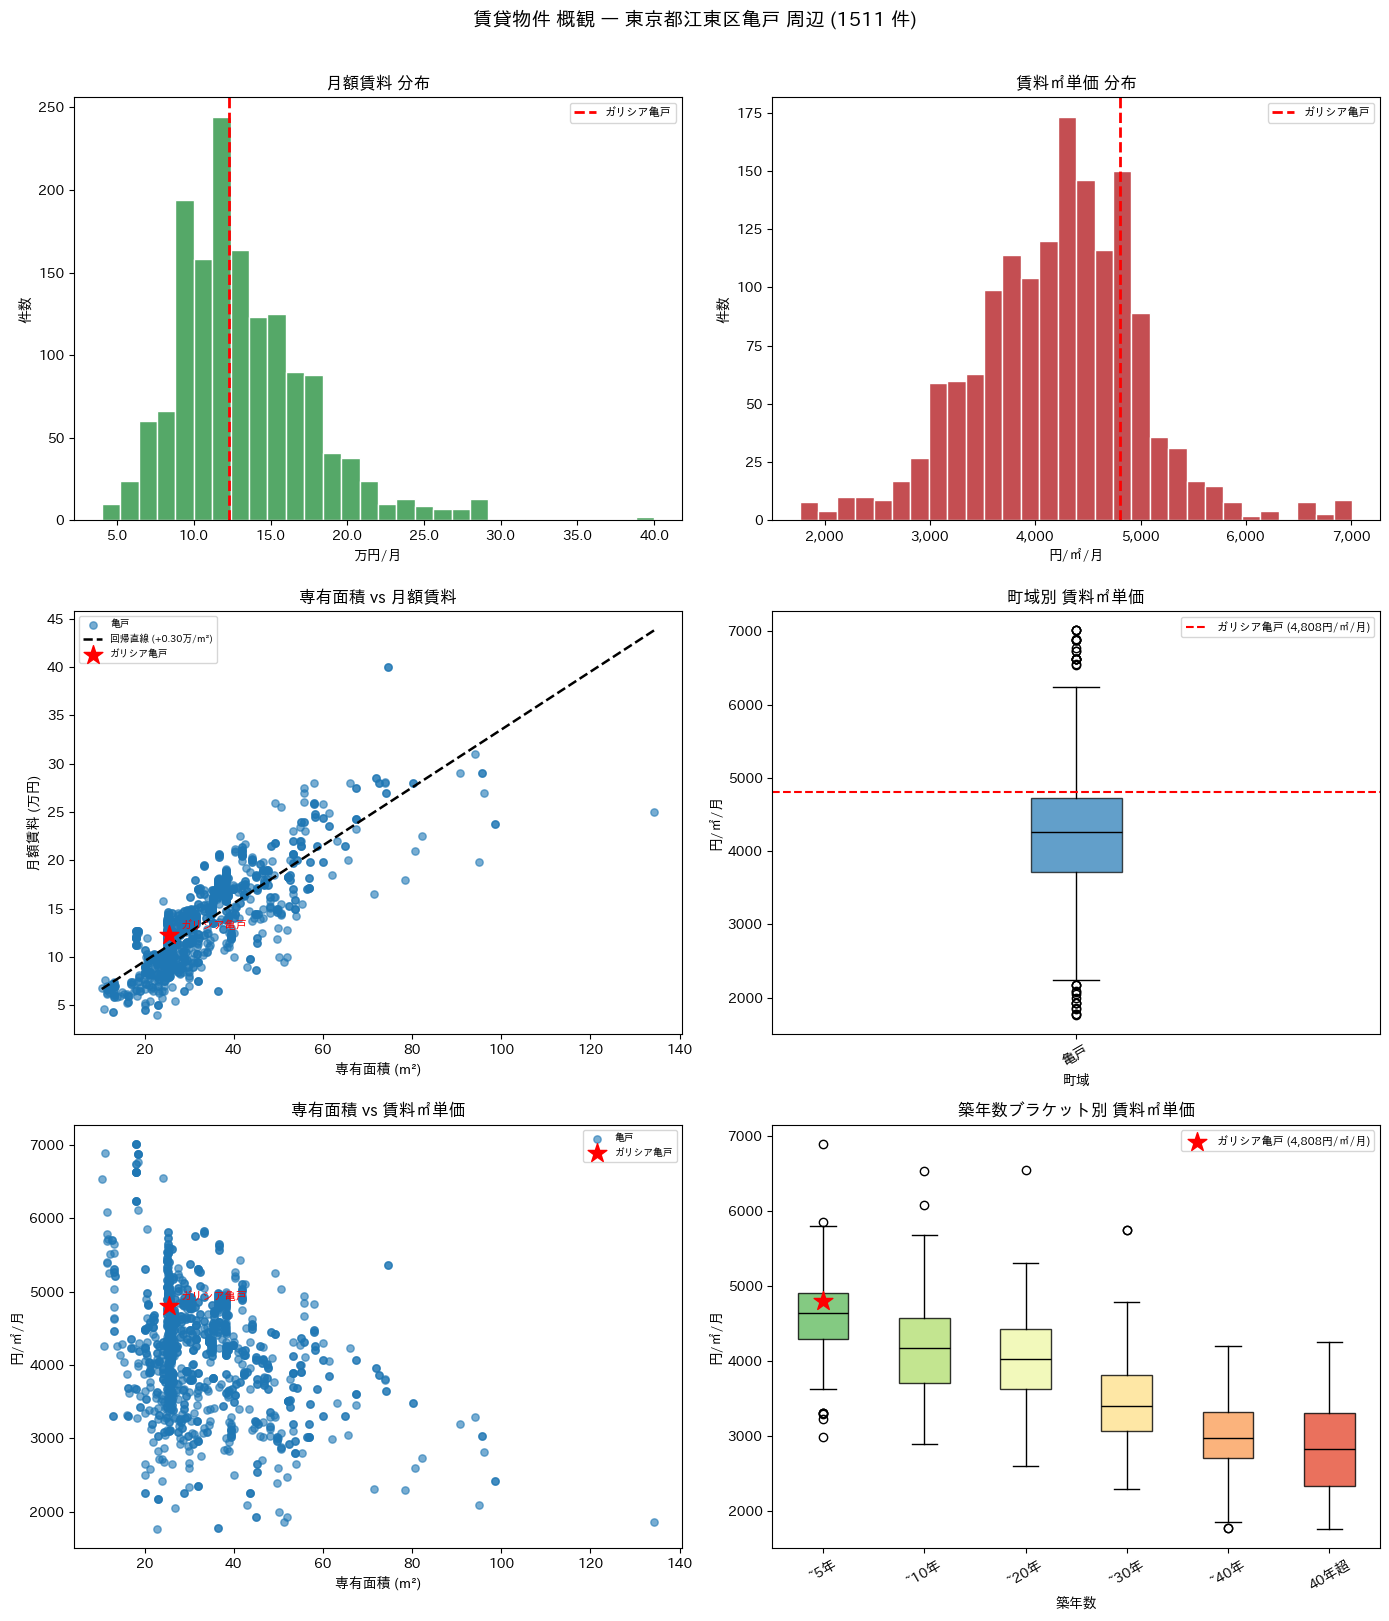

In [28]:
# === 賃貸データ概観チャート（検討物件比較付き） ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import japanize_matplotlib  # noqa: F401

_df = df_rent.dropna(subset=["rent_jpy", "exclusive_area_sqm"]).copy()
if "rent_per_sqm_jpy" not in _df.columns:
    _df["rent_per_sqm_jpy"] = (
        _df["rent_jpy"].astype(float) / _df["exclusive_area_sqm"]
    ).round(0)

_df = _df.dropna(subset=["rent_per_sqm_jpy"]).copy()

if _df.empty:
    print("⚠ チャート作成対象の賃貸データが不足しています（rent_jpy / exclusive_area_sqm が必要）。")
else:
    _df["rent_man"] = _df["rent_jpy"].astype(float) / 1e4  # 万円/月
    _df["rpsqm_jpy"] = _df["rent_per_sqm_jpy"].astype(float)  # 円/㎡/月
    _age_labels = ["~5年", "~10年", "~20年", "~30年", "~40年", "40年超"]

    towns = _df["address_town"].fillna("不明") if "address_town" in _df.columns else pd.Series(["不明"] * len(_df))
    palette = plt.cm.tab10.colors
    town_order = towns.value_counts().index.tolist()

    # 検討物件（設定セルの値）
    _prop_label = PROP_LABEL if "PROP_LABEL" in globals() else None
    _prop_area = float(PROP_AREA_SQM) if "PROP_AREA_SQM" in globals() and PROP_AREA_SQM is not None else None
    _prop_rent_jpy = int(PROP_RENT_JPY) if "PROP_RENT_JPY" in globals() and PROP_RENT_JPY else None
    _prop_rent_man = (_prop_rent_jpy / 1e4) if _prop_rent_jpy is not None else None
    _prop_rpsqm_jpy = (_prop_rent_jpy / _prop_area) if (_prop_rent_jpy is not None and _prop_area) else None

    fig, axes = plt.subplots(3, 2, figsize=(14, 16))
    fig.suptitle(f"賃貸物件 概観 — {TARGET_ADDRESS} 周辺 ({len(_df)} 件)", fontsize=14, y=1.01)

    # ① 賃料ヒストグラム
    ax = axes[0, 0]
    ax.hist(_df["rent_man"], bins=30, color="#55A868", edgecolor="white")
    if _prop_rent_man is not None:
        ax.axvline(_prop_rent_man, color="red", linewidth=2, linestyle="--", label=_prop_label)
    ax.set_title("月額賃料 分布")
    ax.set_xlabel("万円/月")
    ax.set_ylabel("件数")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.1f}"))
    if _prop_rent_man is not None:
        ax.legend(fontsize=8)

    # ② 賃料㎡単価ヒストグラム
    ax = axes[0, 1]
    ax.hist(_df["rpsqm_jpy"], bins=30, color="#C44E52", edgecolor="white")
    if _prop_rpsqm_jpy is not None:
        ax.axvline(_prop_rpsqm_jpy, color="red", linewidth=2, linestyle="--", label=_prop_label)
    ax.set_title("賃料㎡単価 分布")
    ax.set_xlabel("円/㎡/月")
    ax.set_ylabel("件数")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    if _prop_rpsqm_jpy is not None:
        ax.legend(fontsize=8)

    # ③ 専有面積 vs 賃料 + 回帰直線（町域で色分け）
    ax = axes[1, 0]
    for i, town in enumerate(town_order):
        mask = towns == town
        ax.scatter(
            _df.loc[mask, "exclusive_area_sqm"],
            _df.loc[mask, "rent_man"],
            label=town, color=palette[i % len(palette)], alpha=0.6, s=28,
        )
    _x = _df["exclusive_area_sqm"].values.astype(float)
    _y = _df["rent_man"].values.astype(float)
    _valid = np.isfinite(_x) & np.isfinite(_y)
    if _valid.sum() >= 2:
        _coef = np.polyfit(_x[_valid], _y[_valid], 1)
        _xr = np.linspace(_x[_valid].min(), _x[_valid].max(), 200)
        ax.plot(_xr, np.polyval(_coef, _xr), color="black", linewidth=1.8,
                linestyle="--", label=f"回帰直線 ({_coef[0]:+.2f}万/m²)")
    if _prop_area is not None and _prop_rent_man is not None:
        ax.scatter(_prop_area, _prop_rent_man, color="red", s=200, zorder=5, marker="*",
                   label=_prop_label)
        ax.annotate(_prop_label, (_prop_area, _prop_rent_man),
                    textcoords="offset points", xytext=(8, 4), fontsize=8, color="red")
    ax.set_title("専有面積 vs 月額賃料")
    ax.set_xlabel("専有面積 (m²)")
    ax.set_ylabel("月額賃料 (万円)")
    ax.legend(fontsize=7, loc="upper left")

    # ④ 町域別 賃料㎡単価 ボックスプロット
    ax = axes[1, 1]
    town_groups = [_df.loc[towns == t, "rpsqm_jpy"].dropna().values for t in town_order]
    bp = ax.boxplot(town_groups, tick_labels=town_order, patch_artist=True, medianprops={"color": "black"})
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    if _prop_rpsqm_jpy is not None:
        ax.axhline(_prop_rpsqm_jpy, color="red", linewidth=1.5, linestyle="--",
                   label=f"{_prop_label} ({_prop_rpsqm_jpy:,.0f}円/㎡/月)")
    ax.set_title("町域別 賃料㎡単価")
    ax.set_xlabel("町域")
    ax.set_ylabel("円/㎡/月")
    ax.tick_params(axis="x", rotation=30)
    if _prop_rpsqm_jpy is not None:
        ax.legend(fontsize=8)

    # ⑤ 専有面積 vs 賃料㎡単価（町域で色分け）
    ax = axes[2, 0]
    for i, town in enumerate(town_order):
        mask = towns == town
        ax.scatter(
            _df.loc[mask, "exclusive_area_sqm"],
            _df.loc[mask, "rpsqm_jpy"],
            label=town, color=palette[i % len(palette)], alpha=0.6, s=28,
        )
    if _prop_area is not None and _prop_rpsqm_jpy is not None:
        ax.scatter(_prop_area, _prop_rpsqm_jpy, color="red", s=200, zorder=5, marker="*",
                   label=_prop_label)
        ax.annotate(_prop_label, (_prop_area, _prop_rpsqm_jpy),
                    textcoords="offset points", xytext=(8, 4), fontsize=8, color="red")
    ax.set_title("専有面積 vs 賃料㎡単価")
    ax.set_xlabel("専有面積 (m²)")
    ax.set_ylabel("円/㎡/月")
    ax.legend(fontsize=7, loc="upper right")

    # ⑥ 築年数ブラケット別 賃料㎡単価 ボックスプロット
    ax = axes[2, 1]
    if "building_age_bracket" in _df.columns:
        _valid_brackets = [b for b in _age_labels if (_df["building_age_bracket"] == b).sum() > 0]
        _age_groups = [_df.loc[_df["building_age_bracket"] == b, "rpsqm_jpy"].dropna().values for b in _valid_brackets]
        if _age_groups:
            _age_palette = plt.cm.RdYlGn(np.linspace(0.8, 0.15, len(_valid_brackets)))
            bp2 = ax.boxplot(_age_groups, tick_labels=_valid_brackets, patch_artist=True,
                             medianprops={"color": "black"})
            for patch, color in zip(bp2["boxes"], _age_palette):
                patch.set_facecolor(color)
                patch.set_alpha(0.8)
            _prop_bracket_idx = _valid_brackets.index("~5年") + 1 if "~5年" in _valid_brackets else None
            if _prop_bracket_idx and _prop_rpsqm_jpy is not None:
                ax.scatter(_prop_bracket_idx, _prop_rpsqm_jpy, color="red", s=200, zorder=5, marker="*",
                           label=f"{_prop_label} ({_prop_rpsqm_jpy:,.0f}円/㎡/月)")
                ax.legend(fontsize=8)
    ax.set_title("築年数ブラケット別 賃料㎡単価")
    ax.set_xlabel("築年数")
    ax.set_ylabel("円/㎡/月")
    ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

In [29]:
df_rent[df_rent["rent_per_sqm_jpy"] >= 3000].sort_values("rent_per_sqm_jpy", ascending=False)

,property_name,rent_jpy,rent_text,maintenance_fee_jpy,deposit_jpy,deposit_text,key_money_jpy,key_money_text,address,exclusive_area_sqm,layout,floor_number,built_year_month,rent_per_sqm_jpy,address_prefecture,address_municipality,address_town,address_chome,building_age_years,building_age_bracket,detail_url,page_url,source_url,scraped_at,search_address
1069,レピュア錦糸町レジデンスII,127000,12.7万円,12000,0,-,0,-,東京都江東区亀戸３,18.11,1K,<NA>,2026-04,7013,東京都,江東区,亀戸,3,0,NaN,https://suumo.jp/chintai/jnc_000106072991/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
1070,レピュア錦糸町レジデンスII,127000,12.7万円,12000,0,-,0,-,東京都江東区亀戸３,18.11,1K,<NA>,2026-04,7013,東京都,江東区,亀戸,3,0,NaN,https://suumo.jp/chintai/jnc_000106072990/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
1173,ＪＲ総武線 亀戸駅 5階建 新築,127000,12.7万円,12000,0,-,0,-,東京都江東区亀戸３,18.11,1K,<NA>,2026-04,7013,東京都,江東区,亀戸,3,0,NaN,https://suumo.jp/chintai/jnc_000106120173/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
1174,ＪＲ総武線 亀戸駅 5階建 新築,127000,12.7万円,12000,0,-,0,-,東京都江東区亀戸３,18.11,1K,<NA>,2026-04,7013,東京都,江東区,亀戸,3,0,NaN,https://suumo.jp/chintai/jnc_000106146152/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
1012,トア,76000,7.6万円,4000,76000,7.6万円,152000,15.2万円,東京都江東区亀戸３,11.02,1K,2,2024-04,6897,東京都,江東区,亀戸,3,2,~5年,https://suumo.jp/chintai/jnc_000106220886/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,シャンティオン,119000,11.9万円,11000,0,-,0,-,東京都江東区亀戸１,39.49,1LDK,2,1998-04,3013,東京都,江東区,亀戸,1,28,~30年,https://suumo.jp/chintai/jnc_000106240602/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
165,ＪＲ総武線 亀戸駅 8階建 築28年,119000,11.9万円,11000,0,-,0,-,東京都江東区亀戸１,39.49,1LDK,2,1998-04,3013,東京都,江東区,亀戸,1,28,~30年,https://suumo.jp/chintai/jnc_000106240604/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
52,ＪＲ総武線 亀戸駅 8階建 築44年,140000,14万円,0,140000,14万円,280000,28万円,東京都江東区亀戸８,46.48,2LDK,5,1982-04,3012,東京都,江東区,亀戸,8,44,40年超,https://suumo.jp/chintai/jnc_000105577883/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸
113,フォルジュ山田,150000,15万円,10000,150000,15万円,150000,15万円,東京都江東区亀戸７,50.00,2DK,5,1994-04,3000,東京都,江東区,亀戸,7,32,~40年,https://suumo.jp/chintai/jnc_000104295391/?bc=...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,https://suumo.jp/chintai/tokyo/sc_koto/oz_1310...,2026-04-05T02:40:14.871318+00:00,東京都江東区亀戸


---
## 2-1. 地価公示価格の取得（過去10年分）

### データソース
**国土交通省 土地総合情報システム API**  
- エンドポイント: `https://www.land.mlit.go.jp/webland/api/TradeListSearch`
- 不動産取引価格情報 API（公的データ、API キー不要）
- 四半期ごとの取引データを取得し、対象町域の地価時系列を構築する

### 処理フロー
1. 対象市区町村コードで過去10年分の四半期データを API リクエスト
2. レスポンス JSON から必要フィールドを抽出
3. 対象町域でフィルタし、年ごとに集計

### 確認ポイント
- 年度カバレッジ（10年分あるか）
- 価格の桁が妥当か（江東区亀戸なら㎡単価 数十万円〜程度）
- 地点数が十分か

In [30]:

# === 地価公示: API クライアント ===

def fetch_land_prices(
    area_code: str,
    target_town: str,
    years_back: int = YEARS_BACK,
) -> pd.DataFrame:
    """
    国土交通省 不動産情報ライブラリ API (XIT001) から不動産取引価格情報を取得。

    API: https://www.reinfolib.mlit.go.jp/ex-api/external/XIT001
    キー取得: https://www.reinfolib.mlit.go.jp/app/user/create (無料登録)

    Args:
        area_code: 市区町村コード 5桁 (例: '13108' = 江東区)
                   都道府県コードは先頭2桁から自動導出
        target_town: 町名 (例: '亀戸')
        years_back: 遡及年数
    """
    if not REINFOLIB_API_KEY:
        logger.error(
            "REINFOLIB_API_KEY が設定されていません。\n"
            "  1. https://www.reinfolib.mlit.go.jp/app/user/create にアクセス\n"
            "  2. 無料ユーザー登録してAPIキーを取得\n"
            "  3. 設定セルの REINFOLIB_API_KEY = \"...\" に入力して再実行"
        )
        return pd.DataFrame()

    pref_code = area_code[:2]  # 都道府県コード (13108 → 13)
    now = datetime.now()
    api_url = LAND_PRICE_API_URL
    req_headers = {
        "Ocp-Apim-Subscription-Key": REINFOLIB_API_KEY,
        "User-Agent": USER_AGENT,
    }

    all_records: List[Dict] = []
    from_year = now.year - years_back
    total_quarters = 0

    # years_back 年分を四半期ごとに取得
    for year in tqdm(range(from_year, now.year + 1), desc="地価データ取得(年)"):
        max_q = ((now.month - 1) // 3 + 1) if year == now.year else 4
        for q in range(1, max_q + 1):
            total_quarters += 1
            params = {
                "year": str(year),
                "quarter": str(q),
                "area": pref_code,
                "city": area_code,
            }
            time.sleep(random.uniform(REQUEST_SLEEP_MIN, REQUEST_SLEEP_MAX))
            try:
                resp = requests.get(
                    api_url, params=params, headers=req_headers,
                    timeout=REQUEST_TIMEOUT
                )
                if resp.status_code != 200:
                    logger.warning(f"地価API {year}Q{q}: HTTP {resp.status_code}")
                    continue
                records = resp.json().get("data", [])
                all_records.extend(records)
                logger.debug(f"地価API {year}Q{q}: {len(records)} 件")
            except Exception as e:
                logger.warning(f"地価API {year}Q{q}: {e}")

    logger.info(f"地価API: {total_quarters} 四半期 / 合計 {len(all_records)} 件取得")
    return _parse_land_price_results(all_records, target_town, api_url, area_code)


In [31]:

# === reinfolib API 接続テスト（APIキー設定後に実行） ===
# APIキー取得先: https://www.reinfolib.mlit.go.jp/app/user/create
if REINFOLIB_API_KEY:
    _resp_test = requests.get(
        LAND_PRICE_API_URL,
        params={"year": "2024", "quarter": "1", "area": "13", "city": "13108"},
        headers={"Ocp-Apim-Subscription-Key": REINFOLIB_API_KEY, "User-Agent": USER_AGENT},
        timeout=10,
    )
    print(f"status: {_resp_test.status_code}")
    if _resp_test.status_code == 200:
        _d = _resp_test.json()
        print(f"件数: {len(_d.get('data', []))}")
        if _d.get("data"):
            print(f"先頭レコードのキー: {list(_d['data'][0].keys())}")
    else:
        print(f"エラー: {_resp_test.text[:300]}")
else:
    print("⚠ REINFOLIB_API_KEY が未設定です")
    print("  取得先: https://www.reinfolib.mlit.go.jp/app/user/create")


status: 200
件数: 821
先頭レコードのキー: ['PriceCategory', 'Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality', 'DistrictName', 'TradePrice', 'PricePerUnit', 'FloorPlan', 'Area', 'UnitPrice', 'LandShape', 'Frontage', 'TotalFloorArea', 'BuildingYear', 'Structure', 'Use', 'Purpose', 'Direction', 'Classification', 'Breadth', 'CityPlanning', 'CoverageRatio', 'FloorAreaRatio', 'Period', 'Renovation', 'Remarks', 'DistrictCode']


In [32]:
# === 地価公示: レスポンス整形 ===

def _parse_land_price_results(
    raw_records: List[Dict],
    target_town: str,
    api_url: str,
    area_code: str,
) -> pd.DataFrame:
    """
    API レスポンスの生データを整形し、対象町域でフィルタして DataFrame 化する。

    API レスポンスの主なフィールド:
    - Type: 取引種別
    - Region: 地域
    - MunicipalityCode: 市区町村コード
    - Prefecture: 都道府県
    - Municipality: 市区町村
    - DistrictName: 地区名
    - TradePrice: 取引価格
    - PricePerUnit: 坪単価
    - FloorPlan: 間取り
    - Area: 面積(m²)
    - UnitPrice: 単価
    - Period: 取引時期
    """
    parsed = []
    norm_town = normalize_address(target_town)

    for rec in raw_records:
        try:
            district = rec.get("DistrictName", "") or ""
            # 町域フィルタ
            if norm_town and norm_town not in normalize_address(district):
                continue

            # 取引時期を年に変換 (例: "2023年第１四半期" → 2023)
            period = rec.get("Period", "")
            period_norm = unicodedata.normalize("NFKC", str(period))
            year_match = re.search(r"(\d{4})", period_norm)
            year = int(year_match.group(1)) if year_match else None

            # 取引価格
            trade_price = rec.get("TradePrice")
            try:
                trade_price = int(trade_price) if trade_price else None
            except (ValueError, TypeError):
                trade_price = None

            # 面積
            area = rec.get("Area")
            try:
                area_val = float(area) if area else None
            except (ValueError, TypeError):
                area_val = None

            # ㎡単価の計算
            price_per_sqm = None
            if trade_price and area_val and area_val > 0:
                price_per_sqm = int(trade_price / area_val)

            parsed.append({
                "year": year,
                "period": period,
                "trade_price_jpy": trade_price,
                "area_sqm": area_val,
                "price_per_sqm_jpy": price_per_sqm,
                "point_name_or_address": district,
                "target_address": TARGET_ADDRESS,
                "trade_type": rec.get("Type", ""),
                "land_use": rec.get("Use", ""),
                "prefecture": rec.get("Prefecture", ""),
                "municipality": rec.get("Municipality", ""),
                "district": district,
                "floor_plan": rec.get("FloorPlan", ""),
                "building_year": rec.get("BuildingYear", ""),
                "structure": rec.get("Structure", ""),
                "city_planning": rec.get("CityPlanning", ""),
                "source_name": "国土交通省 土地総合情報システム API",
                "source_url": api_url,
                "fetched_at": datetime.now(timezone.utc).isoformat(),
                # TODO: ジオコーディングで緯度経度・距離を追加
                "latitude": None,
                "longitude": None,
                "distance_from_target_m": None,
            })
        except Exception as e:
            logger.warning(f"地価レコードのパース失敗: {e}")
            continue

    if not parsed:
        logger.warning(f"対象町域 '{target_town}' にマッチする地価データがありません")
        return pd.DataFrame()

    df = pd.DataFrame(parsed)

    # 型変換
    for col in ["trade_price_jpy", "price_per_sqm_jpy"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    if "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    df = df.sort_values("year").reset_index(drop=True)

    logger.info(
        f"地価データ: {len(df)} 件 (対象町域='{target_town}', "
        f"年度範囲={df['year'].min()}-{df['year'].max()})"
    )
    return df

In [33]:
# === 地価データ収集: 実行 & プレビュー ===
df_land_price = fetch_land_prices(
    area_code=LAND_PRICE_AREA_CODE,
    target_town=TARGET_TOWN,
    years_back=YEARS_BACK,
)

print(f"\n=== 地価データ概要 ===")
print(f"件数: {len(df_land_price)}")
if not df_land_price.empty:
    print(f"\nカラム一覧:\n{df_land_price.dtypes.to_string()}")

    # 年ごとの集計
    if "year" in df_land_price.columns and "price_per_sqm_jpy" in df_land_price.columns:
        yearly = (
            df_land_price
            .dropna(subset=["year", "price_per_sqm_jpy"])
            .groupby("year")["price_per_sqm_jpy"]
            .agg(["count", "mean", "median", "min", "max"])
            .rename(columns={
                "count": "件数",
                "mean": "平均㎡単価",
                "median": "中央値㎡単価",
                "min": "最小㎡単価",
                "max": "最大㎡単価",
            })
        )
        print(f"\n--- 年別地価推移 ---")
        display(yearly)

    # 取引種別の分布
    if "trade_type" in df_land_price.columns:
        print(f"\n--- 取引種別 ---")
        print(df_land_price["trade_type"].value_counts().to_string())

    if ENABLE_DEBUG_PREVIEW:
        display(df_land_price.head(20))
else:
    print("⚠ 地価データが取得できませんでした。")

地価データ取得(年):   0%|          | 0/11 [00:00<?, ?it/s]

2026-04-05 11:40:54 [WARNING] 地価API 2025Q4: HTTP 404
2026-04-05 11:40:54 [WARNING] 地価API 2026Q1: HTTP 404
2026-04-05 11:40:56 [WARNING] 地価API 2026Q2: HTTP 404
2026-04-05 11:40:56 [INFO] 地価API: 42 四半期 / 合計 20960 件取得
2026-04-05 11:40:56 [INFO] 地価データ: 2725 件 (対象町域='亀戸', 年度範囲=2016-2025)



=== 地価データ概要 ===
件数: 2725

カラム一覧:
year                        Int64
period                     object
trade_price_jpy             Int64
area_sqm                  float64
price_per_sqm_jpy           Int64
point_name_or_address      object
target_address             object
trade_type                 object
land_use                   object
prefecture                 object
municipality               object
district                   object
floor_plan                 object
building_year              object
structure                  object
city_planning              object
source_name                object
source_url                 object
fetched_at                 object
latitude                   object
longitude                  object
distance_from_target_m     object

--- 年別地価推移 ---


,件数,平均㎡単価,中央値㎡単価,最小㎡単価,最大㎡単価
year,,,,,
2016,187,727507.374332,628571.0,62500,3647058
2017,147,695234.904762,614285.0,44444,3444444
2018,163,744258.361963,714285.0,200000,2279069
2019,183,803393.73224,760000.0,92307,2857142
2020,207,883119.183575,880000.0,61538,10500000
2021,382,833538.329843,800000.0,35294,6250000
2022,431,854063.211137,822222.0,186206,7666666
2023,385,872561.002597,866666.0,91666,3291666
2024,344,932644.430233,892820.0,212000,3846153



--- 取引種別 ---
trade_type
中古マンション等     2289
宅地(土地と建物)     318
宅地(土地)        118


,year,period,trade_price_jpy,area_sqm,price_per_sqm_jpy,point_name_or_address,target_address,trade_type,land_use,prefecture,municipality,district,floor_plan,building_year,structure,city_planning,source_name,source_url,fetched_at,latitude,longitude,distance_from_target_m
0,2016,2016年第1四半期,18000000,25.0,720000,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,１Ｋ,2015年,ＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008075+00:00,None,None,None
1,2016,2016年第1四半期,29000000,25.0,1160000,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,１Ｋ,2015年,ＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008086+00:00,None,None,None
2,2016,2016年第1四半期,24000000,50.0,480000,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,３ＬＤＫ,1986年,ＳＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008093+00:00,None,None,None
3,2016,2016年第1四半期,28000000,25.0,1120000,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,１Ｋ,2015年,ＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008098+00:00,None,None,None
4,2016,2016年第1四半期,30000000,25.0,1200000,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,１Ｋ,2015年,ＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008103+00:00,None,None,None
5,2016,2016年第1四半期,8500000,15.0,566666,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,１Ｋ,1992年,ＲＣ,準工業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008107+00:00,None,None,None
6,2016,2016年第1四半期,30000000,30.0,1000000,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,１Ｋ,2015年,ＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008111+00:00,None,None,None
7,2016,2016年第1四半期,29000000,25.0,1160000,亀戸,東京都江東区亀戸,中古マンション等,住宅,東京都,江東区,亀戸,１Ｋ,2015年,ＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008115+00:00,None,None,None
8,2016,2016年第1四半期,50000000,70.0,714285,亀戸,東京都江東区亀戸,宅地(土地と建物),住宅,東京都,江東区,亀戸,,2016年,木造,準工業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008119+00:00,None,None,None
9,2016,2016年第1四半期,1000000000,320.0,3125000,亀戸,東京都江東区亀戸,宅地(土地と建物),共同住宅、駐車場,東京都,江東区,亀戸,,2016年,ＲＣ,商業地域,国土交通省 土地総合情報システム API,https://www.reinfolib.mlit.go.jp/ex-api/extern...,2026-04-05T02:40:56.008123+00:00,None,None,None


,quarter,件数,平均単価(円/㎡),中央値(円/㎡),P10,P90,最小(円/㎡),最大(円/㎡)
0,2016Q1,76,823990.387202,726666.666667,409903.381643,1200000.0,125000.0,3125000.0
1,2016Q2,33,805805.931244,633333.333333,364000.0,1140000.0,138461.538462,3647058.823529
2,2016Q3,34,559715.344332,522727.272727,270000.0,917333.333333,175000.0,1080000.0
3,2016Q4,44,631789.437451,610000.0,295882.352941,907777.777778,62500.0,1109090.909091
4,2017Q1,39,639465.193072,560000.0,306153.846154,1042000.0,77142.857143,1250000.0
5,2017Q2,32,637248.348456,636243.386243,385636.363636,898000.0,44444.444444,1227848.101266
6,2017Q3,43,739318.219095,633333.333333,369333.333333,1128000.0,80000.0,3437500.0
7,2017Q4,33,759933.155509,573333.333333,348533.333333,1120000.0,188888.888889,3444444.444444
8,2018Q1,45,711492.491459,700000.0,408888.888889,1068000.0,304000.0,1150000.0
9,2018Q2,33,723197.121326,687500.0,457212.121212,1074000.0,316666.666667,1120000.0


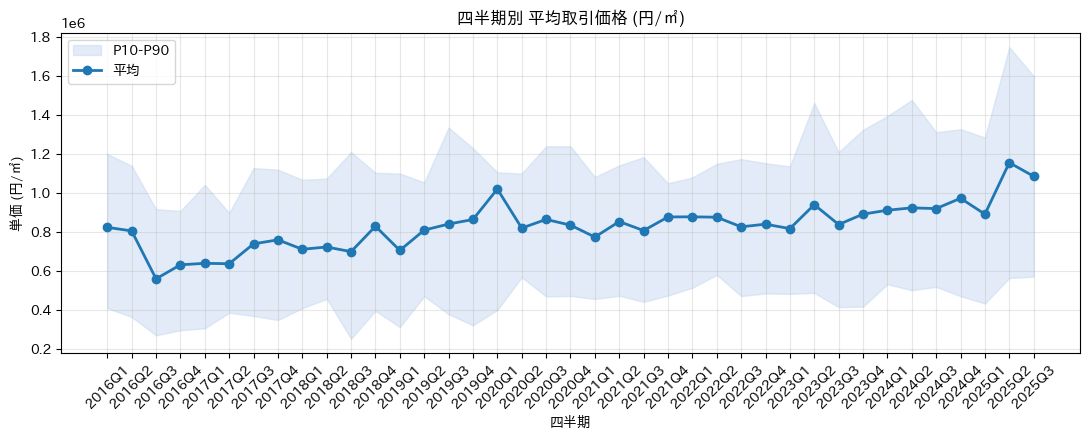


--- 取引種別別 単価統計 ---


,件数,平均単価(円/㎡),中央値(円/㎡),最小(円/㎡),最大(円/㎡),P25,P75
trade_type,,,,,,,
宅地(土地と建物),318,1077224.35923,887301.587302,44444.444444,9333333.333333,582058.823529,1200000.0
中古マンション等,2289,836162.992844,818181.818182,73333.333333,10500000.0,614285.714286,1000000.0
宅地(土地),118,693730.982544,648325.358852,35294.117647,1971428.571429,422916.666667,912500.0



--- 間取り別 単価統計 ---


,件数,平均単価(円/㎡),中央値(円/㎡),最小(円/㎡),最大(円/㎡),P25,P75
floor_plan,,,,,,,
１Ｋ,816,977967.121162,1000000.0,117647.058824,10500000.0,880000.0,1100000.0
,464,969693.46176,840000.0,35294.117647,9333333.333333,509615.384615,1083928.571429
１ＬＤＫ,118,899342.30741,765714.285714,316000.0,2142857.142857,600000.0,1200000.0
１ＤＫ,98,817656.550932,840000.0,220000.0,1971428.571429,480000.0,1000000.0
２ＬＤＫ＋Ｓ,43,807676.277211,666666.666667,285714.285714,1750000.0,583216.783217,940000.0
３ＬＤＫ＋Ｓ,15,805833.701902,635294.117647,487500.0,1733333.333333,588235.294118,972619.047619
１ＬＤＫ＋Ｓ,21,777679.040536,727272.727273,420000.0,1622222.222222,660000.0,836363.636364
３ＬＤＫ,643,762551.444136,700000.0,246153.846154,2142857.142857,586666.666667,866666.666667
４ＬＤＫ,67,761258.822813,682352.941176,357142.857143,2720000.0,588888.888889,784736.842105



--- 構造別 単価統計 ---


,件数,平均単価(円/㎡),中央値(円/㎡),最小(円/㎡),最大(円/㎡),P25,P75
structure,,,,,,,
木造、軽量鉄骨造,1,2037037.037037,2037037.037037,2037037.037037,2037037.037037,2037037.037037,2037037.037037
ブロック造,1,1600000.0,1600000.0,1600000.0,1600000.0,1600000.0,1600000.0
ＲＣ,1415,986258.499903,957142.857143,120000.0,10500000.0,769230.769231,1100000.0
鉄骨造、木造,1,971428.571429,971428.571429,971428.571429,971428.571429,971428.571429,971428.571429
鉄骨造,111,954578.442959,789473.684211,218181.818182,3846153.846154,571282.051282,1050000.0
木造,183,890050.924517,833333.333333,44444.444444,9333333.333333,561666.666667,1056684.491979
,199,730018.049392,714285.714286,35294.117647,2450000.0,475961.538462,924501.424501
軽量鉄骨造,4,682444.00527,572463.768116,366666.666667,1218181.818182,450362.318841,804545.454545
ＳＲＣ,810,643690.809405,615384.615385,73333.333333,2545454.545455,480000.0,750000.0



--- 中古マンション等 × RC/SRC 四半期集計 ---


,quarter,件数,平均単価(円/㎡),中央値(円/㎡),P10,P90,最小(円/㎡),最大(円/㎡)
0,2016Q1,51,766830.141536,733333.333333,430769.230769,1200000.0,220000.0,1240000.0
1,2016Q2,27,707654.004432,626666.666667,372000.0,1088000.0,312000.0,1160000.0
2,2016Q3,27,580179.080179,563636.363636,318285.714286,901333.333333,180000.0,1080000.0
3,2016Q4,28,653749.892964,624285.714286,342000.0,906000.0,212000.0,1100000.0
4,2017Q1,29,689319.875527,615384.615385,392727.272727,1042000.0,250000.0,1200000.0
5,2017Q2,24,661501.949439,669743.589744,445454.545455,894000.0,212000.0,960000.0
6,2017Q3,35,685604.534401,633333.333333,372000.0,1106000.0,208000.0,1200000.0
7,2017Q4,25,674391.226551,573333.333333,367446.153846,1104000.0,300000.0,1200000.0
8,2018Q1,37,713556.934057,750000.0,418461.538462,1088000.0,304000.0,1150000.0
9,2018Q2,30,725739.055681,663750.0,464654.545455,1080000.0,316666.666667,1120000.0


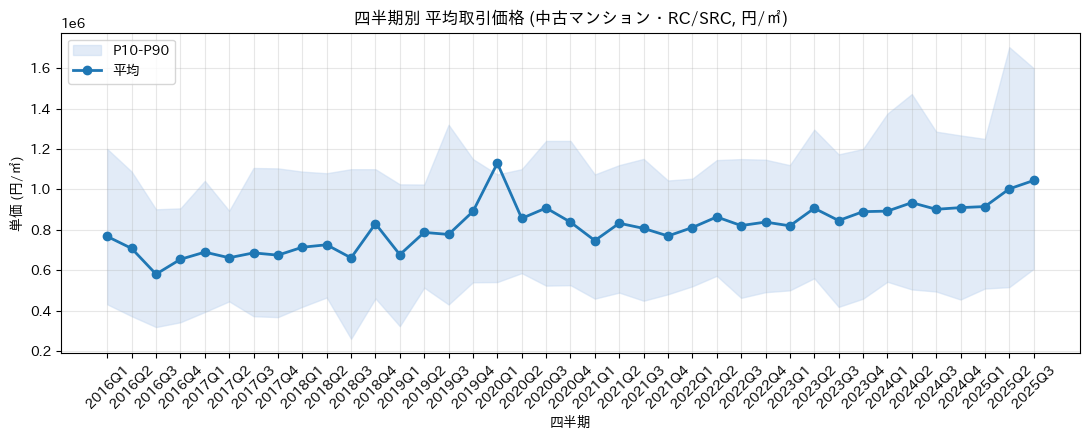

In [34]:
# === 地価データ: 四半期別の平均 trade_price_jpy/area_sqm ===
if df_land_price.empty:
    print("⚠ 地価データがありません。先に取得セルを実行してください。")
else:
    def _period_to_quarter(period: Any) -> Optional[str]:
        if pd.isna(period):
            return None
        norm = unicodedata.normalize("NFKC", str(period))
        year_match = re.search(r"(\d{4})", norm)
        quarter_match = re.search(r"(?:第)?\s*([1-4])\s*四半期", norm)
        if not (year_match and quarter_match):
            return None
        return f"{year_match.group(1)}Q{quarter_match.group(1)}"

    def _norm_structure(val: Any) -> Optional[str]:
        if pd.isna(val):
            return None
        return unicodedata.normalize("NFKC", str(val)).upper().strip()

    df_q = df_land_price.copy()
    df_q["quarter"] = df_q.get("period").apply(_period_to_quarter) if "period" in df_q.columns else None

    df_q["price_per_sqm_calc"] = (
        pd.to_numeric(df_q.get("trade_price_jpy"), errors="coerce")
        / pd.to_numeric(df_q.get("area_sqm"), errors="coerce")
    )
    df_q = df_q.replace([np.inf, -np.inf], np.nan)

    quarterly = (
        df_q
        .dropna(subset=["quarter", "price_per_sqm_calc"])
        .groupby("quarter")["price_per_sqm_calc"]
        .agg(["count", "mean", "median", "min", "max",
              lambda s: s.quantile(0.1),
              lambda s: s.quantile(0.9)])
        .rename(columns={
            "count": "件数",
            "mean": "平均単価(円/㎡)",
            "median": "中央値(円/㎡)",
            "min": "最小(円/㎡)",
            "max": "最大(円/㎡)",
            "<lambda_0>": "P10",
            "<lambda_1>": "P90",
        })
        .reset_index()
    )
    quarterly["period_idx"] = pd.PeriodIndex(quarterly["quarter"], freq="Q")
    quarterly = quarterly.sort_values("period_idx")

    display(quarterly[["quarter", "件数", "平均単価(円/㎡)", "中央値(円/㎡)", "P10", "P90", "最小(円/㎡)", "最大(円/㎡)"]])

    if not quarterly.empty:
        import warnings
        import matplotlib.pyplot as plt

        try:
            import japanize_matplotlib  # noqa: F401
        except ImportError:
            warnings.filterwarnings("ignore", message=r"Glyph .* missing")
            warnings.filterwarnings("ignore", message=r"findfont: Font family.*IPAex")
            warnings.warn("japanize_matplotlib が未インストールのためデフォルトフォントで描画します。", RuntimeWarning)

        fig, ax = plt.subplots(figsize=(11, 4.5))
        x = quarterly["period_idx"].astype(str)
        y = quarterly["平均単価(円/㎡)"]
        p10 = quarterly["P10"]
        p90 = quarterly["P90"]
        ax.fill_between(x, p10, p90, color="#c6d9f1", alpha=0.5, label="P10-P90")
        ax.plot(x, y, marker="o", color="#1f77b4", linewidth=2, label="平均")
        ax.set_title("四半期別 平均取引価格 (円/㎡)")
        ax.set_xlabel("四半期")
        ax.set_ylabel("単価 (円/㎡)")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ 四半期ごとの平均値を計算できませんでした。")

    # 取引種別・間取り・構造ごとの集計
    def _group_summary(col: str) -> pd.DataFrame:
        if col not in df_q.columns:
            return pd.DataFrame()
        return (
            df_q.dropna(subset=[col, "price_per_sqm_calc"])
            .groupby(col)["price_per_sqm_calc"]
            .agg(["count", "mean", "median", "min", "max",
                  lambda s: s.quantile(0.25),
                  lambda s: s.quantile(0.75)])
            .rename(columns={
                "count": "件数",
                "mean": "平均単価(円/㎡)",
                "median": "中央値(円/㎡)",
                "min": "最小(円/㎡)",
                "max": "最大(円/㎡)",
                "<lambda_0>": "P25",
                "<lambda_1>": "P75",
            })
            .sort_values("平均単価(円/㎡)", ascending=False)
        )

    for _col, _label in [("trade_type", "取引種別別"), ("floor_plan", "間取り別"), ("structure", "構造別")]:
        _df = _group_summary(_col)
        if not _df.empty:
            print(f"\n--- {_label} 単価統計 ---")
            display(_df)
        else:
            print(f"\n⚠ {_label} データが不足しています")

    # 中古マンション等 × RC/SRC のフィルタ版
    df_condo = df_q.copy()
    df_condo["structure_norm"] = df_condo.get("structure").apply(_norm_structure) if "structure" in df_condo.columns else None
    df_condo = df_condo[
        (df_condo.get("trade_type") == "中古マンション等")
        & (df_condo.get("structure_norm").isin(["RC", "SRC"]))
    ]

    if df_condo.empty:
        print("\n⚠ 中古マンション等かつRC/SRCのデータがありません。")
    else:
        df_condo["quarter"] = df_condo.get("period").apply(_period_to_quarter) if "period" in df_condo.columns else None
        quarterly_c = (
            df_condo
            .dropna(subset=["quarter", "price_per_sqm_calc"])
            .groupby("quarter")["price_per_sqm_calc"]
            .agg(["count", "mean", "median", "min", "max",
                  lambda s: s.quantile(0.1),
                  lambda s: s.quantile(0.9)])
            .rename(columns={
                "count": "件数",
                "mean": "平均単価(円/㎡)",
                "median": "中央値(円/㎡)",
                "min": "最小(円/㎡)",
                "max": "最大(円/㎡)",
                "<lambda_0>": "P10",
                "<lambda_1>": "P90",
            })
            .reset_index()
        )
        quarterly_c["period_idx"] = pd.PeriodIndex(quarterly_c["quarter"], freq="Q")
        quarterly_c = quarterly_c.sort_values("period_idx")

        print("\n--- 中古マンション等 × RC/SRC 四半期集計 ---")
        display(quarterly_c[["quarter", "件数", "平均単価(円/㎡)", "中央値(円/㎡)", "P10", "P90", "最小(円/㎡)", "最大(円/㎡)"]])

        if not quarterly_c.empty:
            import warnings
            import matplotlib.pyplot as plt
            try:
                import japanize_matplotlib  # noqa: F401
            except ImportError:
                warnings.filterwarnings("ignore", message=r"Glyph .* missing")
                warnings.filterwarnings("ignore", message=r"findfont: Font family.*IPAex")
                warnings.warn("japanize_matplotlib が未インストールのためデフォルトフォントで描画します。", RuntimeWarning)

            fig, ax = plt.subplots(figsize=(11, 4.5))
            x2 = quarterly_c["period_idx"].astype(str)
            y2 = quarterly_c["平均単価(円/㎡)"]
            p10c = quarterly_c["P10"]
            p90c = quarterly_c["P90"]
            ax.fill_between(x2, p10c, p90c, color="#c6d9f1", alpha=0.5, label="P10-P90")
            ax.plot(x2, y2, marker="o", color="#1f77b4", linewidth=2, label="平均")
            ax.set_title("四半期別 平均取引価格 (中古マンション・RC/SRC, 円/㎡)")
            ax.set_xlabel("四半期")
            ax.set_ylabel("単価 (円/㎡)")
            ax.grid(True, alpha=0.3)
            ax.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print("⚠ 四半期ごとの集計を計算できませんでした。")

---
## データ品質チェック & サマリ

全3データセットの品質を横断的に確認する。  
以下が OK なら保存に進む:
- null 率が許容範囲内か
- 重複行がないか
- 価格の桁が妥当か（外れ値フラグ）

---
## データ保存 (CSV / Parquet)

- CSV: 人間が目視確認しやすい形式
- Parquet: 後続分析で高速に読み込み可能な列指向形式
- ファイル名にタイムスタンプを含め、実行ごとの履歴を保持

In [35]:
# === データ保存 ===

def save_dataframe(
    df: pd.DataFrame,
    name: str,
    output_dir: Path = PROCESSED_DIR,
    town: str = TARGET_TOWN,
) -> List[Path]:
    """
    DataFrame を CSV と Parquet の両方で保存する。

    Returns:
        保存したファイルパスのリスト
    """
    if df.empty:
        logger.warning(f"{name}: データが空のため保存をスキップ")
        return []

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    saved_files = []

    for fmt, ext in [("csv", ".csv"), ("parquet", ".parquet")]:
        file_path = output_dir / f"{name}_{town}_{timestamp}{ext}"
        try:
            if fmt == "csv":
                df.to_csv(file_path, index=False, encoding="utf-8-sig")
            else:
                df.to_parquet(file_path, index=False, engine="pyarrow")

            size_kb = file_path.stat().st_size / 1024
            print(f"  ✅ {file_path} ({size_kb:.1f} KB, {len(df)} rows)")
            saved_files.append(file_path)

        except ImportError as e:
            if "pyarrow" in str(e):
                logger.warning(f"pyarrow 未インストールのため Parquet 保存をスキップ: {e}")
            else:
                raise
        except Exception as e:
            logger.error(f"{name} の {fmt} 保存失敗: {e}")

    return saved_files


if ENABLE_SAVE:
    print("=== データ保存開始 ===\n")

    saved = {}
    for name, df in [
        ("sale_listings", df_sale),
        ("rent_listings", df_rent),
        ("land_prices", df_land_price),
    ]:
        print(f"[{name}]")
        saved[name] = save_dataframe(df, name)
        print()

    # 保存ファイルの検証（読み戻し）
    print("--- 検証: 読み戻し ---")
    for name, paths in saved.items():
        for p in paths:
            if p.suffix == ".csv":
                df_check = pd.read_csv(p)
                print(f"  {p.name}: {df_check.shape}")
            elif p.suffix == ".parquet":
                try:
                    df_check = pd.read_parquet(p)
                    print(f"  {p.name}: {df_check.shape}")
                except ImportError:
                    print(f"  {p.name}: (pyarrow 未インストール — スキップ)")
else:
    print("ENABLE_SAVE=False のため保存をスキップ")

=== データ保存開始 ===

[sale_listings]
  ✅ output/processed/sale_listings_亀戸_20260405_114056.csv (111.1 KB, 190 rows)
  ✅ output/processed/sale_listings_亀戸_20260405_114056.parquet (28.1 KB, 190 rows)

[rent_listings]
  ✅ output/processed/rent_listings_亀戸_20260405_114056.csv (587.4 KB, 1511 rows)
  ✅ output/processed/rent_listings_亀戸_20260405_114056.parquet (77.7 KB, 1511 rows)

[land_prices]
  ✅ output/processed/land_prices_亀戸_20260405_114056.csv (847.4 KB, 2725 rows)
  ✅ output/processed/land_prices_亀戸_20260405_114056.parquet (53.5 KB, 2725 rows)

--- 検証: 読み戻し ---
  sale_listings_亀戸_20260405_114056.csv: (190, 24)
  sale_listings_亀戸_20260405_114056.parquet: (190, 24)
  rent_listings_亀戸_20260405_114056.csv: (1511, 25)
  rent_listings_亀戸_20260405_114056.parquet: (1511, 25)
  land_prices_亀戸_20260405_114056.csv: (2725, 22)
  land_prices_亀戸_20260405_114056.parquet: (2725, 22)


---
## Next Steps（今後の拡張計画）

この Notebook で収集した3つの DataFrame は、以下の拡張に対応できるスキーマ設計になっている。

### 1. キャッシュフローシミュレーション
- `df_sale` の取得コストと `df_rent` の想定賃料から表面利回り・NOI を算出
- ローン条件・管理費・修繕積立金を加味した実質利回りの計算
- 空室率シナリオ分析

### 2. ジオコーディング統合
- `match_address()` の `matching_strategy='geocoding'` を実装
- 距離ベースの物件マッチング（最寄り地価公示地点の特定等）
- `distance_from_target_m` 列の実値化

### 3. 自動化・スケジューリング
- `papermill` による Notebook のパラメータ付き自動実行
- cron / GitHub Actions での定期収集

### 4. 追加データソース
- LIFULL HOME'S、at home 等の競合サイト
- 不動産取引価格情報（成約価格データ）
- 人口動態・インフラ整備データとの重ね合わせ

### 5. データベース化
- SQLite / PostgreSQL への蓄積で時系列トラッキング
- 物件の出現・消失（売約済み・成約）の追跡